In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
df = pd.read_csv("MotorVehicleCollisions.csv")
df.head()

C:\Users\magnu\AppData\Local\Temp\ipykernel_38096\3258834222.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MotorVehicleCollisions.csv")


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,"40,62179","-73,970024","(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


# Definition of event:

Scope: Police-reported collisions involving injuries, fatalities, or damage over 


In [2]:
is_kill_bal = df["NUMBER OF PERSONS KILLED"] == df["NUMBER OF MOTORIST KILLED"] + df["NUMBER OF CYCLIST KILLED"] + df["NUMBER OF PEDESTRIANS KILLED"]
len(is_kill_bal[is_kill_bal==False])

113

In [3]:
is_inj_bal = df["NUMBER OF PERSONS INJURED"] == df["NUMBER OF MOTORIST INJURED"] + df["NUMBER OF CYCLIST INJURED"] + df["NUMBER OF PEDESTRIANS INJURED"]
len(is_inj_bal[is_inj_bal==False])

10640

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Memory used: ", df.memory_usage(index=True).sum()/10_48_576)

Number of rows: 2253192
Number of columns: 29
Memory used:  498.524356842041


In [5]:
df.shape
df.dtypes
df.duplicated().sum()
df['COLLISION_ID'].duplicated().sum()

0

In [6]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': df.isna().mean().mul(100).round(2)
}).sort_values('n_missing', ascending=False)

missing.head(20)

,n_missing,pct_missing
VEHICLE TYPE CODE 5,2243302,99.56
CONTRIBUTING FACTOR VEHICLE 5,2242979,99.55
VEHICLE TYPE CODE 4,2217260,98.41
CONTRIBUTING FACTOR VEHICLE 4,2215899,98.34
VEHICLE TYPE CODE 3,2096532,93.05
CONTRIBUTING FACTOR VEHICLE 3,2090099,92.76
OFF STREET NAME,1851532,82.17
CROSS STREET NAME,862706,38.29
ZIP CODE,687745,30.52
BOROUGH,687462,30.51


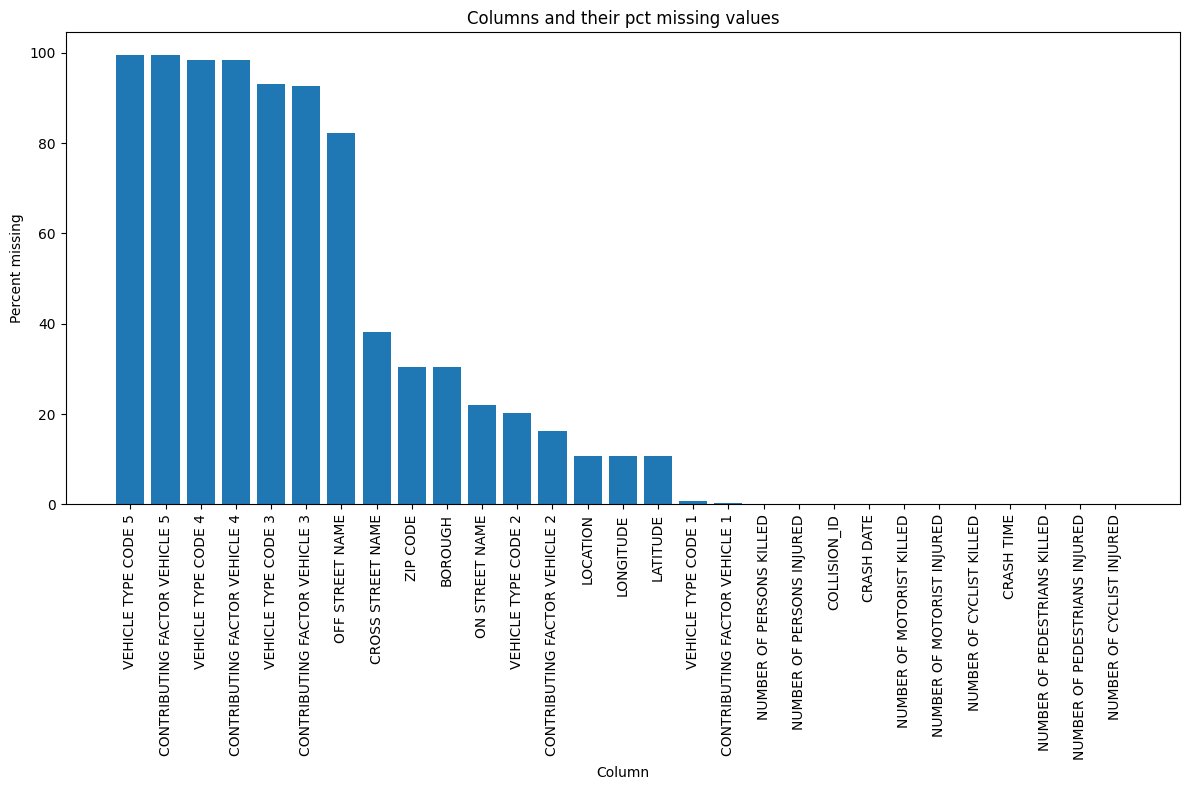

In [7]:
plt.figure(figsize=(12, 8))
plt.bar(missing.index.astype(str), missing["pct_missing"])
plt.xticks(rotation=90)
plt.ylabel("Percent missing")
plt.xlabel("Column")
plt.title("Columns and their pct missing values")
plt.tight_layout()
plt.show()

In [8]:
# parse date/time
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

df['CRASH DATETIME'] = (
    df['CRASH DATE'].dt.normalize() +
    pd.to_timedelta(df['CRASH TIME'].dt.hour, unit='h') +
    pd.to_timedelta(df['CRASH TIME'].dt.minute, unit='m')
)
print("Date range:")
print("Start:", df["CRASH DATETIME"].min())
print("End:", df["CRASH DATETIME"].max())

# convert lat/lon if commas are decimal separators
for col in ['LATITUDE', 'LONGITUDE']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .replace(['nan', 'None'], pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
    

Date range:
Start: 2012-07-01 00:05:00
End: 2026-04-03 23:41:00


In [9]:
# Drop rows that dont have spatial or temporal information avaliable.
df_clean =df.dropna(subset=['LATITUDE', 'LONGITUDE','CRASH DATETIME','NUMBER OF PERSONS KILLED','NUMBER OF PERSONS INJURED']).copy()
df_clean.head()
df_clean = df_clean.drop(columns=['CRASH DATE', 'CRASH TIME','LOCATION','VEHICLE TYPE CODE 5','CONTRIBUTING FACTOR VEHICLE 5',
                 'VEHICLE TYPE CODE 4','VEHICLE TYPE CODE 3','CONTRIBUTING FACTOR VEHICLE 4','CONTRIBUTING FACTOR VEHICLE 3',
                 "OFF STREET NAME"])

Notes on data preprocessing:

* Rows represent collision events or incidents. 
* No duplicate rows were found "COLLISION_ID" is unique
* Many missing values are found specifically in columns such as VEHICLE TYPE CODE (X>=3) CONTRIBUTING FACTOR VEHICLE (X>=3) which is most likely due to many collisions not including over 2 contributing factors or vehicles. These are all removed. Further "OFF STREET NAME" is removed since it had high pct missing values. 
* (Maybe all location identifies except LAT/LON?)
* A new column that represent both date and time in datetime format is created. The old two columns are removed
* Latitude and Longitude columns are normalized to be seperated by "."
* Data is cleaned by removing all rows that do not have any spatial or tempral information. It was however seen that no date or time values were missing.
* Also rows where number of person injured/killed are removed since we want to investigate these things. I have decided not to fill these rows since it could possibly inflate the data to represent something that we do not know anything about.

In [10]:
print("Number of rows in cleaned data:", df_clean.shape[0])
print("Number of rows dropped:", df.shape[0]-df_clean.shape[0])
print("Number of columns in cleaned data:", df_clean.shape[1])
print("Number of columns dropped:", df.shape[1]-df_clean.shape[1])
print("Date range in cleaned data:")
print("Start:", df_clean["CRASH DATETIME"].min())
print("End:", df_clean["CRASH DATETIME"].max())

Number of rows in cleaned data: 2012482
Number of rows dropped: 240710
Number of columns in cleaned data: 20
Number of columns dropped: 10
Date range in cleaned data:
Start: 2012-07-01 00:05:00
End: 2026-04-03 23:41:00


To make the data complete, years that are incomplete with data will be dropped. The data start in the middle of 2012 and ends during 2026 hence we will drop these two years:

In [11]:
df_clean = df_clean[~df_clean["CRASH DATETIME"].dt.year.isin([2012, 2026])].copy()
df_clean["BOROUGH"] = df_clean["BOROUGH"].fillna("UNKNOWN")
print("Start:", df_clean["CRASH DATETIME"].min())
print("End:", df_clean["CRASH DATETIME"].max())

Start: 2013-01-01 00:01:00
End: 2025-12-31 23:58:00


Fill in borough information given lat/lon coordinates

In [12]:
import geopandas as gpd
from shapely.geometry import Point
# -----------------------------------
# 1) Copy and clean crash data
# -----------------------------------
df_boro = df_clean.copy()

# Clean borough field
df_boro["BOROUGH"] = (
    df_boro["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .replace("", "Unspecified")
)

# -----------------------------------
# 2) Convert crashes to GeoDataFrame
# -----------------------------------
gdf_crashes = gpd.GeoDataFrame(
    df_boro,
    geometry=gpd.points_from_xy(df_boro["LONGITUDE"], df_boro["LATITUDE"]),
    crs="EPSG:4326"
)

# -----------------------------------
# 3) Make sure borough polygons are in same CRS
# -----------------------------------
borough_geojson_url = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson"
boro_gdf = gpd.read_file(borough_geojson_url)
boro_gdf_match = boro_gdf.copy()

if boro_gdf_match.crs is None:
    boro_gdf_match = boro_gdf_match.set_crs("EPSG:4326")
elif boro_gdf_match.crs != gdf_crashes.crs:
    boro_gdf_match = boro_gdf_match.to_crs(gdf_crashes.crs)

# -----------------------------------
# 4) Identify borough-name column
# -----------------------------------
possible_boro_cols = ["boroname"]
boro_name_col = next((c for c in possible_boro_cols if c in boro_gdf_match.columns), None)

if boro_name_col is None:
    raise ValueError("Could not find borough name column in boro_gdf")

# Keep only needed polygon columns
boro_lookup = boro_gdf_match[[boro_name_col, "geometry"]].copy()

# -----------------------------------
# 5) Spatial join: assign each crash point to a borough polygon
# -----------------------------------
gdf_joined = gpd.sjoin(
    gdf_crashes,
    boro_lookup,
    how="left",
    predicate="within"
)

# -----------------------------------
# 6) Fill missing/unspecified BOROUGH using spatially assigned borough
# -----------------------------------
needs_fill = gdf_joined["BOROUGH"].str.lower().isin(["unspecified", "unknown", "nan"])

gdf_joined.loc[needs_fill, "BOROUGH"] = gdf_joined.loc[needs_fill, boro_name_col].str.upper()

# Optional cleanup for rows still unmatched
gdf_joined["BOROUGH"] = gdf_joined["BOROUGH"].fillna("Unspecified")

# -----------------------------------
# 7) Write back to original dataframe
# -----------------------------------
df_clean_filled = df_clean.copy()
df_clean_filled["BOROUGH"] = (
    df_clean_filled["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .replace("", "Unspecified")
)

# Update only the rows that had valid coordinates and were spatially matched
df_clean_filled.loc[gdf_joined.index, "BOROUGH"] = gdf_joined["BOROUGH"]

# -----------------------------------
# 8) Quick diagnostics
# -----------------------------------
before_unspecified = (
    df_clean["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["unspecified", "unknown", ""])
).sum()

after_unspecified = (
    df_clean_filled["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["unspecified", "unknown", ""])
).sum()

print(f"Unspecified/unknown boroughs before fill: {before_unspecified}")
print(f"Unspecified/unknown boroughs after fill:  {after_unspecified}")

Unspecified/unknown boroughs before fill: 472110
Unspecified/unknown boroughs after fill:  9896


In [13]:
df_clean_filled["BOROUGH"].unique()

array(['BROOKLYN', 'BRONX', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND',
       'Unspecified'], dtype=object)

This got most of them filled in -> the rest of them i am gonna remove

In [14]:
df_clean = df_clean_filled.copy()
df_clean = df_clean[
    ~df_clean["BOROUGH"].isin(["Unspecified"])
].copy()

Remove rows where mismatch in number of person and the subcategories:

In [15]:
# main dataset for category analysis
df_clean = df_clean.copy()

# strict consistency subset
df_clean = df_clean[
    ~(
        (df_clean["NUMBER OF PERSONS INJURED"] != (
            df_clean["NUMBER OF PEDESTRIANS INJURED"]
            + df_clean["NUMBER OF CYCLIST INJURED"]
            + df_clean["NUMBER OF MOTORIST INJURED"]
        ))
        |
        (df_clean["NUMBER OF PERSONS KILLED"] != (
            df_clean["NUMBER OF PEDESTRIANS KILLED"]
            + df_clean["NUMBER OF CYCLIST KILLED"]
            + df_clean["NUMBER OF MOTORIST KILLED"]
        ))
    )
].copy()

In [15]:
df_clean.shape

(1887039, 20)

# When, Where and who are the NYC streets most dangerous for in terms of crashes?

## Distributions

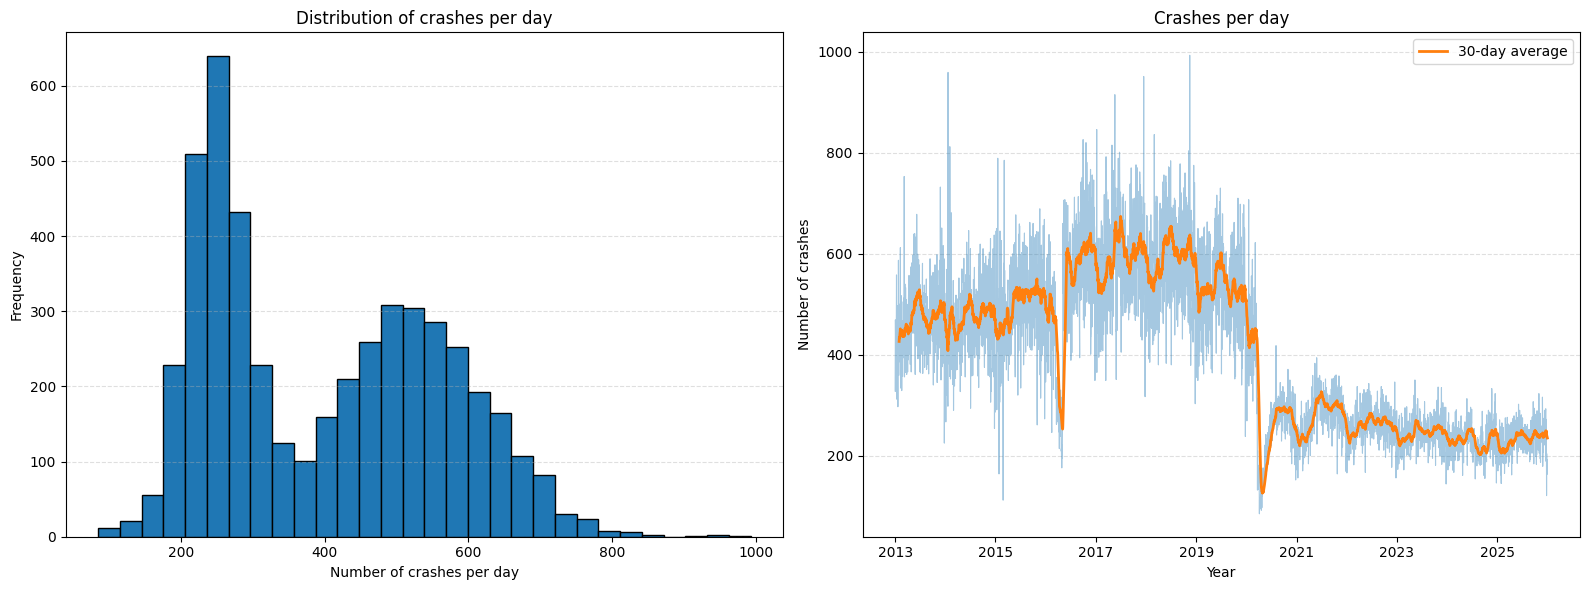

In [ ]:
crashes_per_day = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.date)
      .size()
)

rolling_30 = crashes_per_day.rolling(30).mean()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(crashes_per_day, bins=30,edgecolor="black")
axes[0].set_xlabel("Number of crashes per day")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of crashes per day")
axes[0].grid(True,axis="y",linestyle="--",alpha=0.4)

axes[1].plot(crashes_per_day.index, crashes_per_day.values, linewidth=0.8, alpha=0.4)
axes[1].plot(rolling_30.index, rolling_30.values, linewidth=2, label="30-day average")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of crashes")
axes[1].set_title("Crashes per day trend")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[1].set_axisbelow(True)

tick_years = pd.date_range("2013-01-01", crashes_per_day.index.max(), freq="2YS")
axes[1].set_xticks(tick_years)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].legend()

plt.tight_layout()
plt.show()

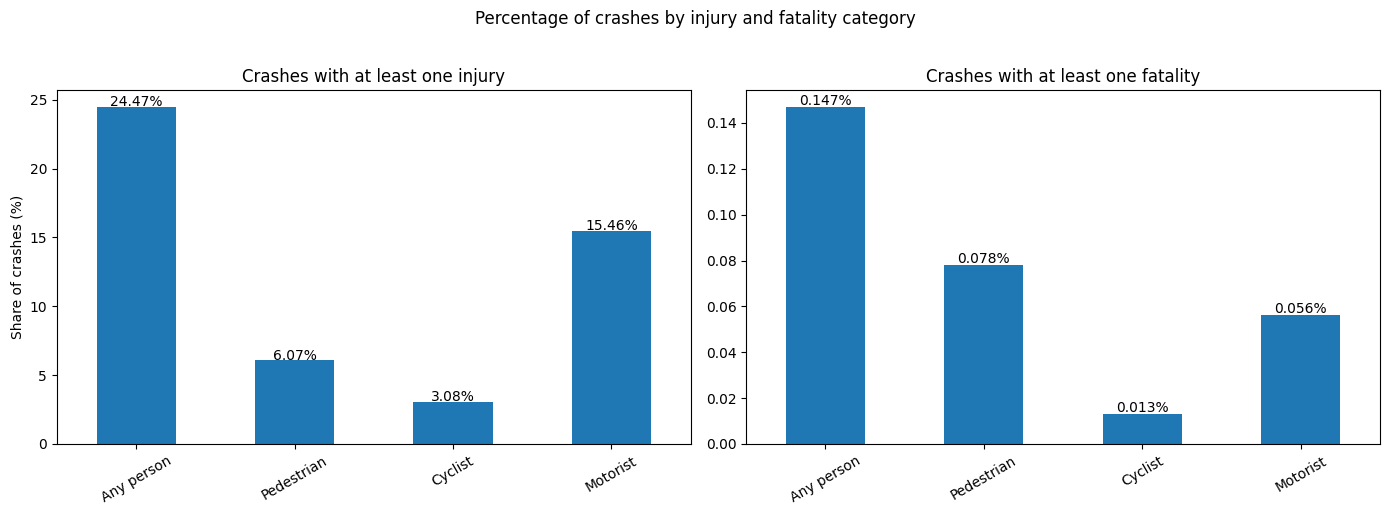

In [54]:
# Fraction of crashes with at least one injury in each category
injury_fractions = {
    "Any person": (df_clean["NUMBER OF PERSONS INJURED"] > 0).mean(),
    "Pedestrian": (df_clean["NUMBER OF PEDESTRIANS INJURED"] > 0).mean(),
    "Cyclist": (df_clean["NUMBER OF CYCLIST INJURED"] > 0).mean(),
    "Motorist": (df_clean["NUMBER OF MOTORIST INJURED"] > 0).mean(),
}

# Fraction of crashes with at least one fatality in each category
fatality_fractions = {
    "Any person": (df_clean["NUMBER OF PERSONS KILLED"] > 0).mean(),
    "Pedestrian": (df_clean["NUMBER OF PEDESTRIANS KILLED"] > 0).mean(),
    "Cyclist": (df_clean["NUMBER OF CYCLIST KILLED"] > 0).mean(),
    "Motorist": (df_clean["NUMBER OF MOTORIST KILLED"] > 0).mean(),
}

injury_series = pd.Series(injury_fractions) * 100
fatality_series = pd.Series(fatality_fractions) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: injuries
ax1 = axes[0]
injury_series.plot(kind="bar", ax=ax1)
ax1.set_title("Crashes with at least one injury")
ax1.set_ylabel("Share of crashes (%)")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=30)

for i, v in enumerate(injury_series):
    ax1.text(i, v + 0.05, f"{v:.2f}%", ha="center")

# Right plot: fatalities
ax2 = axes[1]
fatality_series.plot(kind="bar", ax=ax2)
ax2.set_title("Crashes with at least one fatality")
#ax2.set_ylabel("Share of crashes (%)")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=30)

for i, v in enumerate(fatality_series):
    ax2.text(i, v + max(fatality_series) * 0.03 - 0.0035, f"{v:.3f}%", ha="center")

plt.suptitle("Percentage of crashes by injury and fatality category", y=1.02)
plt.tight_layout()
plt.show()

Generally we can see that the distribution seems to be bimodal.

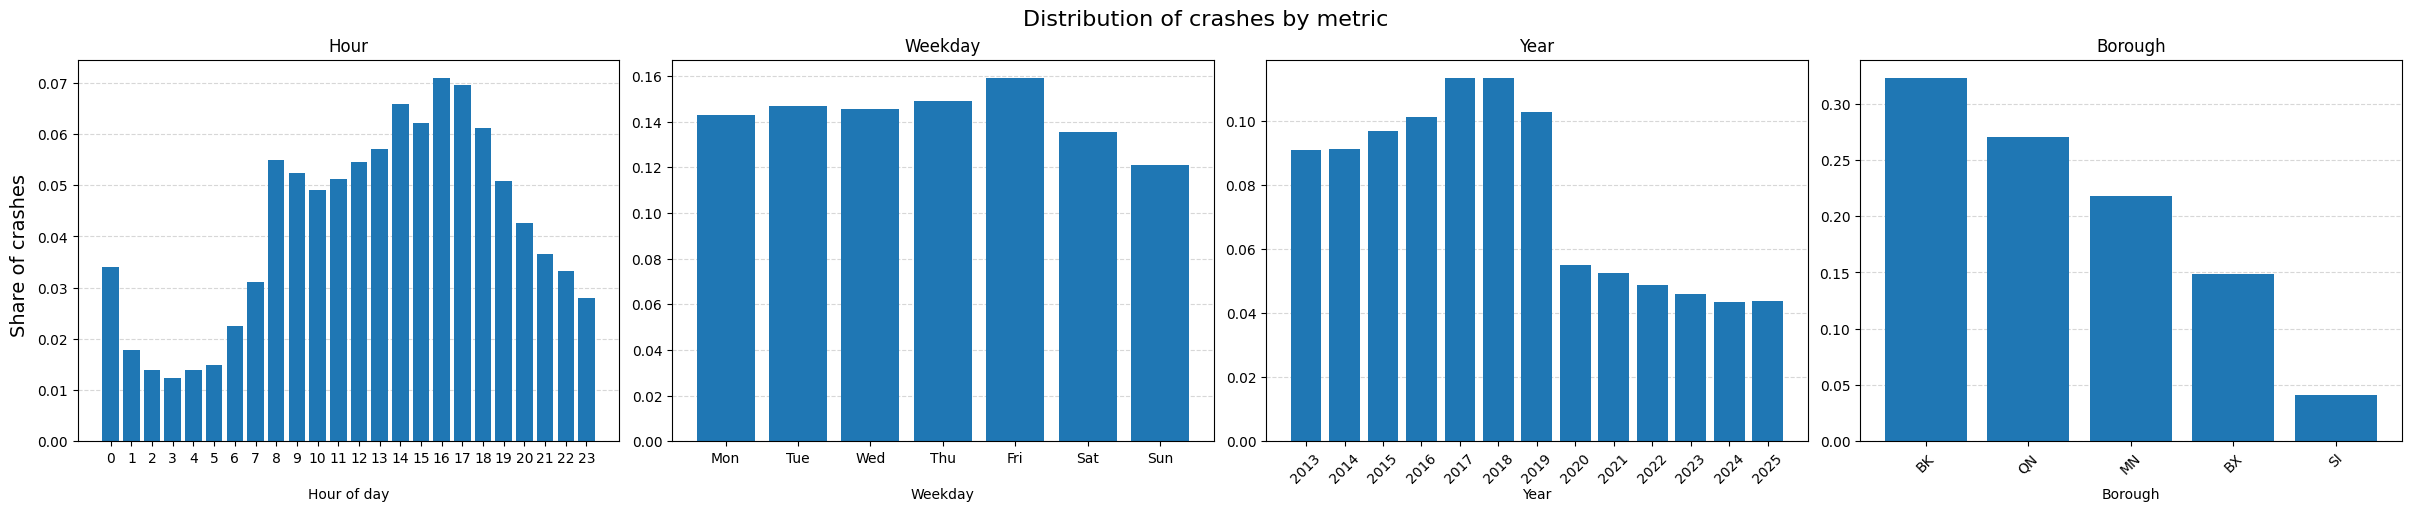

In [26]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
crashes_by_weekday = (
    df_clean.assign(weekday=df_clean["CRASH DATETIME"].dt.strftime("%a"))
    .groupby("weekday")
    .size()
    .reindex(weekday_order, fill_value=0)
)


crashes_by_hour = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.hour)
    .size()
    .reindex(range(24), fill_value=0)
)


crashes_by_year = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.year)
    .size()
    .sort_index()
)


borough_map = {
    "BRONX": "BX",
    "BROOKLYN": "BK",
    "MANHATTAN": "MN",
    "QUEENS": "QN",
    "STATEN ISLAND": "SI",
    "Unknown": "NA"
}

crashes_by_borough = (
    df_clean["BOROUGH"]
      .fillna("Unknown")
      .replace(borough_map)
      .value_counts()
      .reindex(["BX", "BK", "MN", "QN", "SI"], fill_value=0)
)

crashes_by_hour_share = crashes_by_hour / crashes_by_hour.sum()
crashes_by_weekday_share = crashes_by_weekday / crashes_by_weekday.sum()
crashes_by_year_share = crashes_by_year / crashes_by_year.sum()
crashes_by_borough = crashes_by_borough.sort_values(ascending=False)
crashes_by_borough_share = crashes_by_borough / crashes_by_borough.sum()

fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)

axes[0].bar(crashes_by_hour.index, crashes_by_hour_share.values)
axes[0].set_title("Hour")
axes[0].set_xlabel("Hour of day")
axes[0].set_xticks(range(24))

axes[1].bar(crashes_by_weekday.index, crashes_by_weekday_share.values)
axes[1].set_title("Weekday")
axes[1].set_xlabel("Weekday")

axes[2].bar(crashes_by_year.index.astype(str), crashes_by_year_share.values)
axes[2].set_title("Year")
axes[2].set_xlabel("Year")
axes[2].tick_params(axis="x", rotation=45)

axes[3].bar(crashes_by_borough.index.astype(str), crashes_by_borough_share.values)
axes[3].set_title("Borough")
axes[3].set_xlabel("Borough")
axes[3].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.xaxis.set_label_coords(0.5, -0.12)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.suptitle("Distribution of crashes by metric", fontsize=16)
fig.supylabel("Share of crashes", fontsize=14)

plt.show()

There is a lower share of crashes during the night hours while most of the crashes occur during 8:00-18:00 where it begins to decrease. This seems to indicate that most incidents occur during the day hours when most people are active on streets. The weekday distribution incidate that Mon-Thu get the same share of crashes while Friday see a slight increase. The weekend seem to a lower share of incidents compared to the weekdays. The yearly distribution shows a slight increase in incidents from 2013-2017. 2018 looks similar in share as 2017 and 2019 is slightly lower. There is a large drop from 2019 to 2020, whereafter a consistent decrease in events happen each year toward 2025. The distribution over Borough indicates that there is a large share of incidents which does not have a documented borough, which was also seen in the preprocessing. Looking further we can see that the Bronx has most crashes. Queens has the second largest, following Manhatten, Brooklyn and lastly Staten Island.

In [13]:
df_clean.columns

Index(['BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'ON STREET NAME',
       'CROSS STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'COLLISION_ID', 'VEHICLE TYPE CODE 1',
       'VEHICLE TYPE CODE 2', 'CRASH DATETIME'],
      dtype='object')

In [27]:
injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

# make sure numeric
for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# long format for boxplots
injured_long = df_clean[injured_cols].melt(var_name="Metric", value_name="Count").dropna()
killed_long = df_clean[killed_cols].melt(var_name="Metric", value_name="Count").dropna()

# flattened values for histograms
injured_vals = injured_long["Count"]
killed_vals = killed_long["Count"]

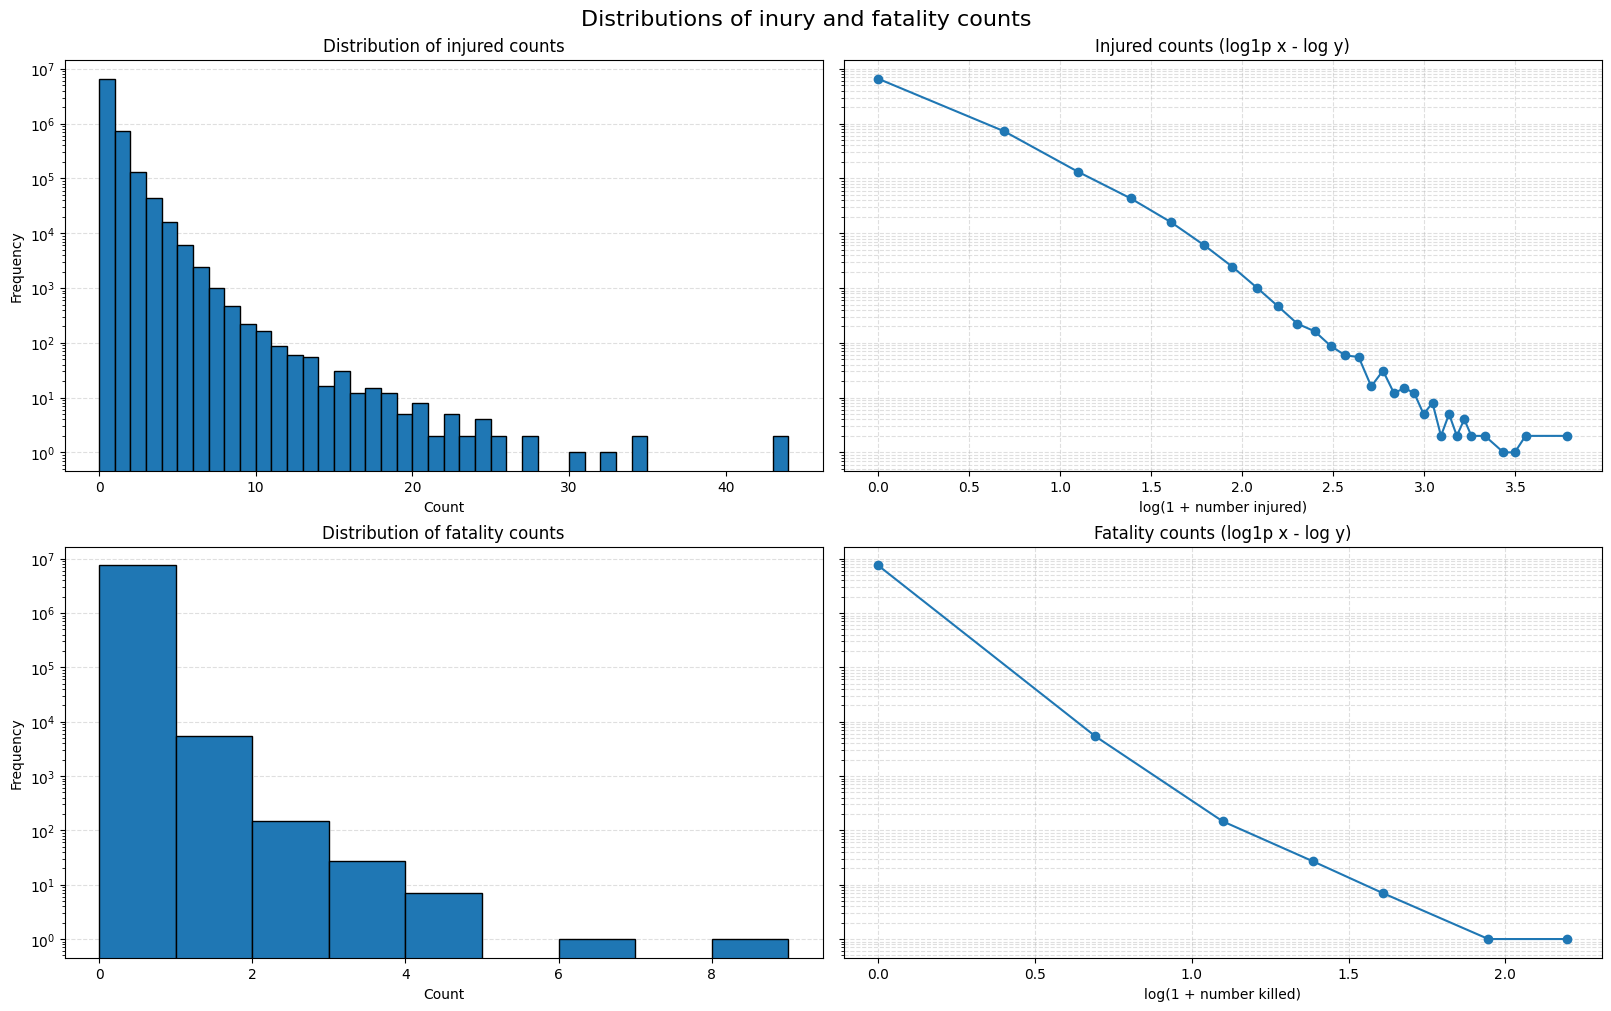

In [28]:
injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

# make sure numeric
for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# long format for boxplots
injured_long = df_clean[injured_cols].melt(var_name="Metric", value_name="Count").dropna()
killed_long = df_clean[killed_cols].melt(var_name="Metric", value_name="Count").dropna()

# flattened values for histograms
injured_vals = injured_long["Count"]
killed_vals = killed_long["Count"]

injured_freq = injured_vals.value_counts().sort_index()
killed_freq = killed_vals.value_counts().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True,sharey='row')
fig.suptitle("Distributions of inury and fatality counts", fontsize=16)
# injured histogram
axes[0, 0].hist(injured_vals, bins=range(0, int(injured_vals.max()) + 2), edgecolor="black")
axes[0, 0].set_title("Distribution of injured counts")
axes[0, 0].set_xlabel("Count")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[0, 0].set_axisbelow(True)
axes[0, 0].set_yscale("log")

# injured boxplot
axes[0,1].plot(np.log1p(injured_freq.index), injured_freq.values,marker="o", linestyle="-")
#axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")
axes[0,1].set_title("Injured counts (log1p x - log y)")
axes[0,1].set_xlabel("log(1 + number injured)")
#axes[0,1].set_ylabel("Frequency")
axes[0,1].grid(True, which="both", linestyle="--", alpha=0.4)

# killed histogram
axes[1, 0].hist(killed_vals, bins=range(0, int(killed_vals.max()) + 2), edgecolor="black")
axes[1, 0].set_title("Distribution of fatality counts")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[1, 0].set_axisbelow(True)
axes[1, 0].set_yscale("log")

# killed boxplot
axes[1,1].plot(np.log1p(killed_freq.index), killed_freq.values,marker="o", linestyle="-")
#axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")
axes[1,1].set_title("Fatality counts (log1p x - log y)")
axes[1,1].set_xlabel("log(1 + number killed)")
#axes[1,1].set_ylabel("Frequency")
axes[1,1].grid(True, which="both", linestyle="--", alpha=0.4)

plt.show()

Distributions are dominated by low counts of both injury/fatalities. There is a heavy tail behvaior with power law indicating that most crashes has either no injuries/fatalities or few. There are however some large outliers which gives a heavy tail.

In [29]:
inj_check = (
    df_clean["NUMBER OF PERSONS INJURED"]
    - (
        df_clean["NUMBER OF PEDESTRIANS INJURED"]
        + df_clean["NUMBER OF CYCLIST INJURED"]
        + df_clean["NUMBER OF MOTORIST INJURED"]
    )
)

kil_check = (
    df_clean["NUMBER OF PERSONS KILLED"]
    - (
        df_clean["NUMBER OF PEDESTRIANS KILLED"]
        + df_clean["NUMBER OF CYCLIST KILLED"]
        + df_clean["NUMBER OF MOTORIST KILLED"]
    )
)

print("Injury mismatches:", (inj_check != 0).sum())
print("Killed mismatches:", (kil_check != 0).sum())

Injury mismatches: 0
Killed mismatches: 0


In [30]:
df_clean.shape

(1887039, 20)

Most times the number of persons injured/killed match the sum of the three categories. This is why we are gonna fix it such that its 

In [31]:
mask_inj = inj_check != 0
df_clean.loc[
    mask_inj,
    [
        "NUMBER OF PERSONS INJURED",
        "NUMBER OF PEDESTRIANS INJURED",
        "NUMBER OF CYCLIST INJURED",
        "NUMBER OF MOTORIST INJURED",
    ]
].head(20)

,NUMBER OF PERSONS INJURED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF CYCLIST INJURED,NUMBER OF MOTORIST INJURED


So the number of persons injured is not exactly just the sum of everyone injured? Maybe number of persons include passengers in vehicles for example or something else?

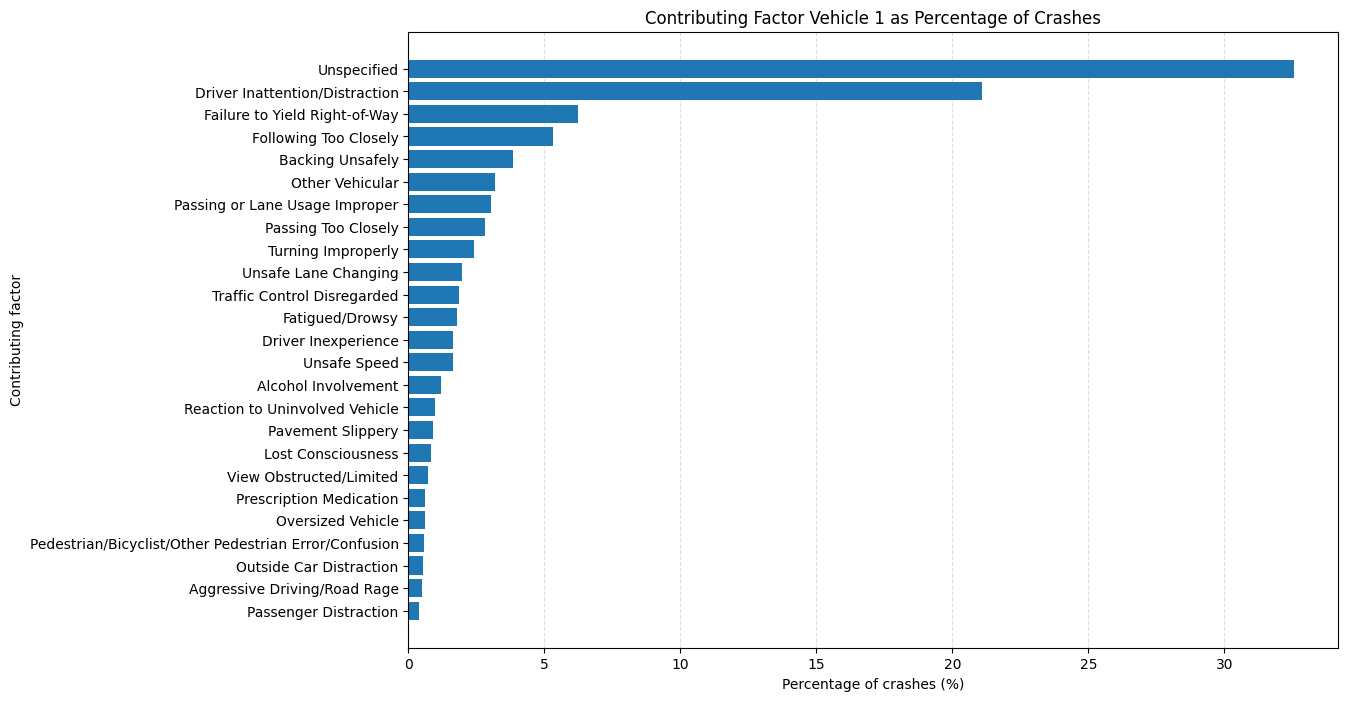

In [32]:
# Fill missing values
df_clean["CONTRIBUTING FACTOR VEHICLE 1"] = (
    df_clean["CONTRIBUTING FACTOR VEHICLE 1"]
    .fillna("Unspecified")
)

# Percentage distribution
factor_pct = (
    df_clean["CONTRIBUTING FACTOR VEHICLE 1"]
    .value_counts(normalize=True)
    .mul(100)
    .head(25)
    .sort_values()
)

# Plot
plt.figure(figsize=(12, 8))
plt.barh(factor_pct.index, factor_pct.values)
plt.xlabel("Percentage of crashes (%)")
plt.ylabel("Contributing factor")
plt.title("Contributing Factor Vehicle 1 as Percentage of Crashes")
plt.grid(True, axis="x", linestyle="--", alpha=0.4)
plt.gca().set_axisbelow(True)
plt.show()

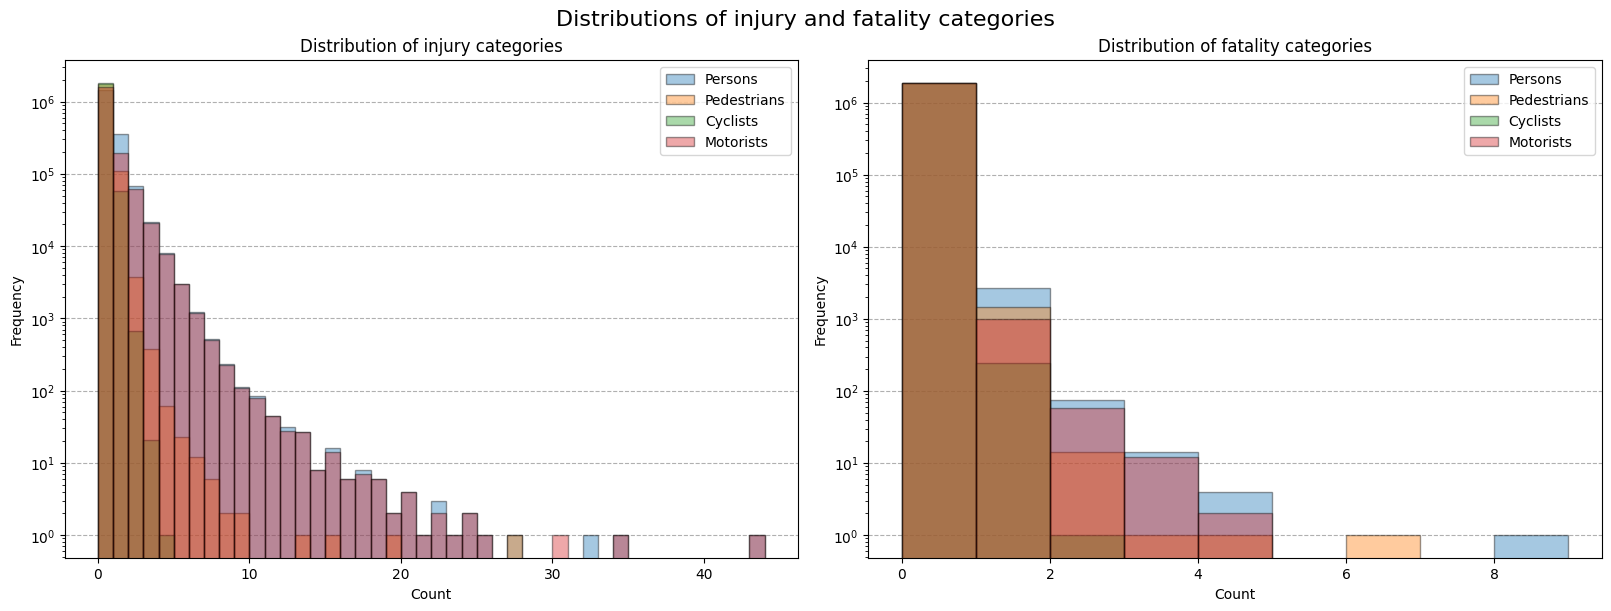

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

injury_labels = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

fatality_labels = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

# make sure numeric
for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# ----- injuries -----
inj_bins = range(
    0,
    int(df_clean[injured_cols].max().max()) + 2
)

for col in injured_cols:
    vals = df_clean[col].dropna()
    axes[0].hist(
        vals,
        bins=inj_bins,
        alpha=0.4,
        #density=True,
        #histtype="step",
        label=injury_labels[col],
        edgecolor="black"
    )

axes[0].set_title("Distribution of injury categories")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")
axes[0].grid(True, axis="y", linestyle="--", alpha=1.0)
axes[0].set_axisbelow(True)
axes[0].legend()

# ----- fatalities -----
kill_bins = range(
    0,
    int(df_clean[killed_cols].max().max()) + 2
)

for col in killed_cols:
    vals = df_clean[col].dropna()
    axes[1].hist(
        vals,
        bins=kill_bins,
        alpha=0.4,
        #density=True,
        #histtype="step",
        label=fatality_labels[col],
        edgecolor="black"
    )

axes[1].set_title("Distribution of fatality categories")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")
axes[1].grid(True, axis="y", linestyle="--", alpha=1.0)
axes[1].set_axisbelow(True)
axes[1].legend()

fig.suptitle("Distributions of injury and fatality categories", fontsize=16)

plt.show()

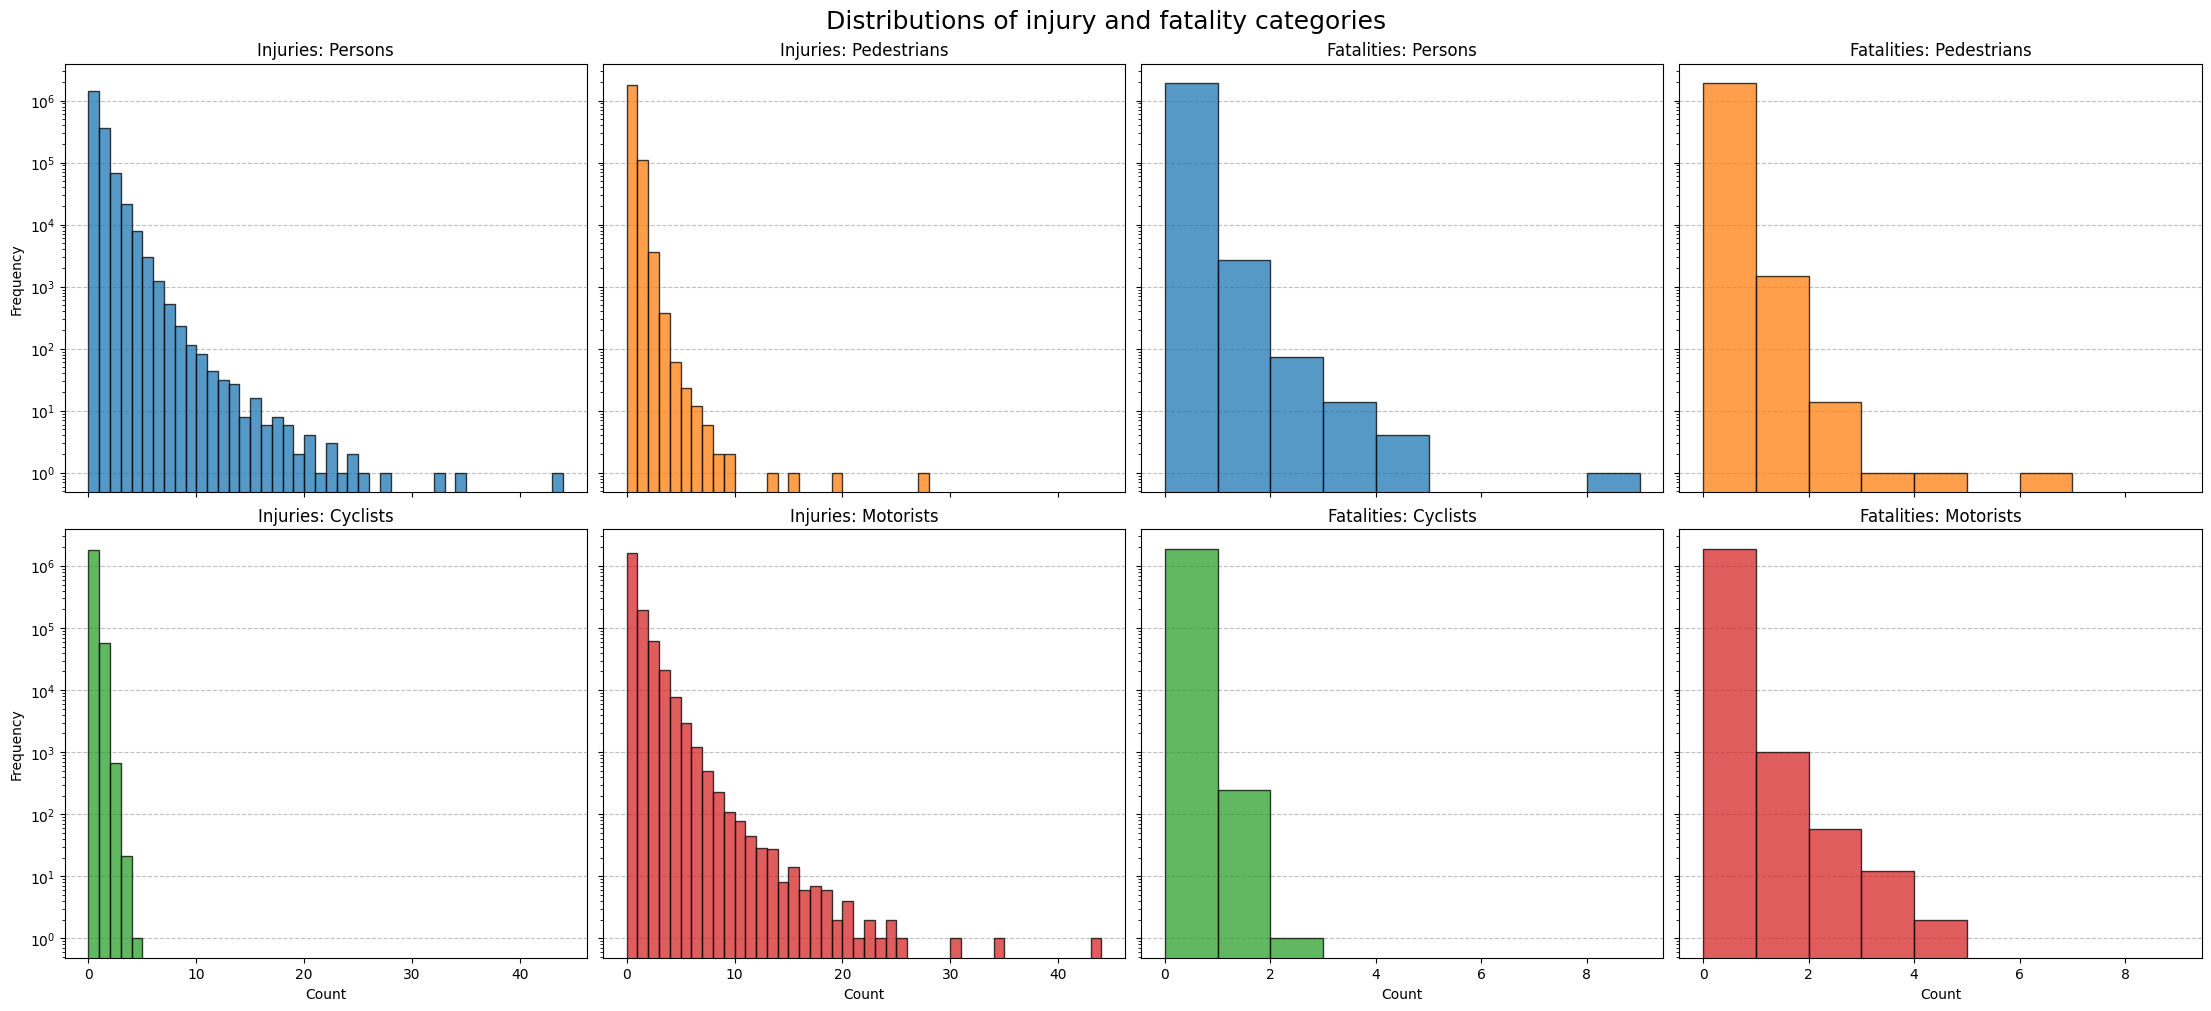

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

injury_labels = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

fatality_labels = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

injury_colors = {
    "NUMBER OF PERSONS INJURED": "tab:blue",
    "NUMBER OF PEDESTRIANS INJURED": "tab:orange",
    "NUMBER OF CYCLIST INJURED": "tab:green",
    "NUMBER OF MOTORIST INJURED": "tab:red",
}

fatality_colors = {
    "NUMBER OF PERSONS KILLED": "tab:blue",
    "NUMBER OF PEDESTRIANS KILLED": "tab:orange",
    "NUMBER OF CYCLIST KILLED": "tab:green",
    "NUMBER OF MOTORIST KILLED": "tab:red",
}

# make sure numeric
for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# separate binning for each side
inj_bins = range(0, int(df_clean[injured_cols].max().max()) + 2)
kill_bins = range(0, int(df_clean[killed_cols].max().max()) + 2)

# 2 rows x 4 columns
fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True, sharey='row',sharex='col')

# -----------------------------------
# Left side: injuries (2x2 block)
# -----------------------------------
inj_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for (r, c), col in zip(inj_positions, injured_cols):
    ax = axes[r, c]
    vals = df_clean[col].dropna()

    ax.hist(
        vals,
        bins=inj_bins,
        color=injury_colors[col],
        alpha=0.75,
        edgecolor="black",
        label=injury_labels[col]
    )

    ax.set_title(f"Injuries: {injury_labels[col]}")
    #ax.set_xlabel("Count")
    ax.set_yscale("log")
    ax.grid(True, axis="y", linestyle="--", alpha=0.8)
    ax.set_axisbelow(True)
    #ax.legend()

# -----------------------------------
# Right side: fatalities (2x2 block)
# -----------------------------------
kill_positions = [(0, 2), (0, 3), (1, 2), (1, 3)]

for (r, c), col in zip(kill_positions, killed_cols):
    ax = axes[r, c]
    vals = df_clean[col].dropna()

    ax.hist(
        vals,
        bins=kill_bins,
        color=fatality_colors[col],
        alpha=0.75,
        edgecolor="black",
        label=fatality_labels[col]
    )

    ax.set_title(f"Fatalities: {fatality_labels[col]}")
    ax.set_yscale("log")
    #ax.set_xlabel("Count")
    ax.grid(True, axis="y", linestyle="--", alpha=0.8)
    ax.set_axisbelow(True)
    #ax.legend()

# y-labels only on far left and start of fatality block
axes[0, 0].set_ylabel("Frequency")
axes[1, 0].set_ylabel("Frequency")
axes[1,0].set_xlabel("Count")
axes[1,1].set_xlabel("Count")
axes[1,2].set_xlabel("Count")
axes[1,3].set_xlabel("Count")
#axes[0, 2].set_ylabel("Frequency")
#axes[1, 2].set_ylabel("Frequency")

fig.suptitle("Distributions of injury and fatality categories", fontsize=18)

plt.show()

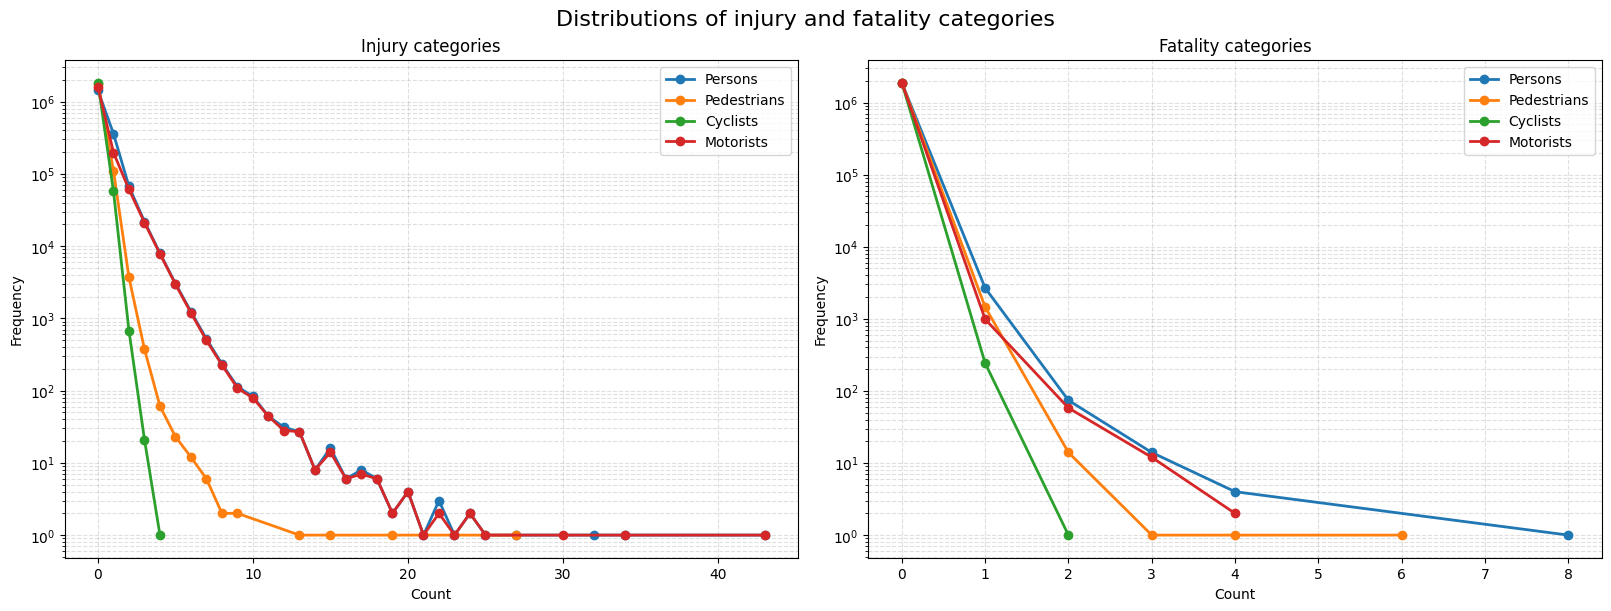

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

labels_inj = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

labels_kil = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# injuries
for col in injured_cols:
    freq = df_clean[col].dropna().astype(int).value_counts().sort_index()
    axes[0].plot(freq.index, freq.values, marker="o", linewidth=2, label=labels_inj[col])

axes[0].set_title("Injury categories")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")
axes[0].grid(True, which="both", linestyle="--", alpha=0.4)
axes[0].legend()

# fatalities
for col in killed_cols:
    freq = df_clean[col].dropna().astype(int).value_counts().sort_index()
    axes[1].plot(freq.index, freq.values, marker="o", linewidth=2, label=labels_kil[col])

axes[1].set_title("Fatality categories")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle="--", alpha=0.4)
axes[1].legend()

fig.suptitle("Distributions of injury and fatality categories", fontsize=16)
plt.show()

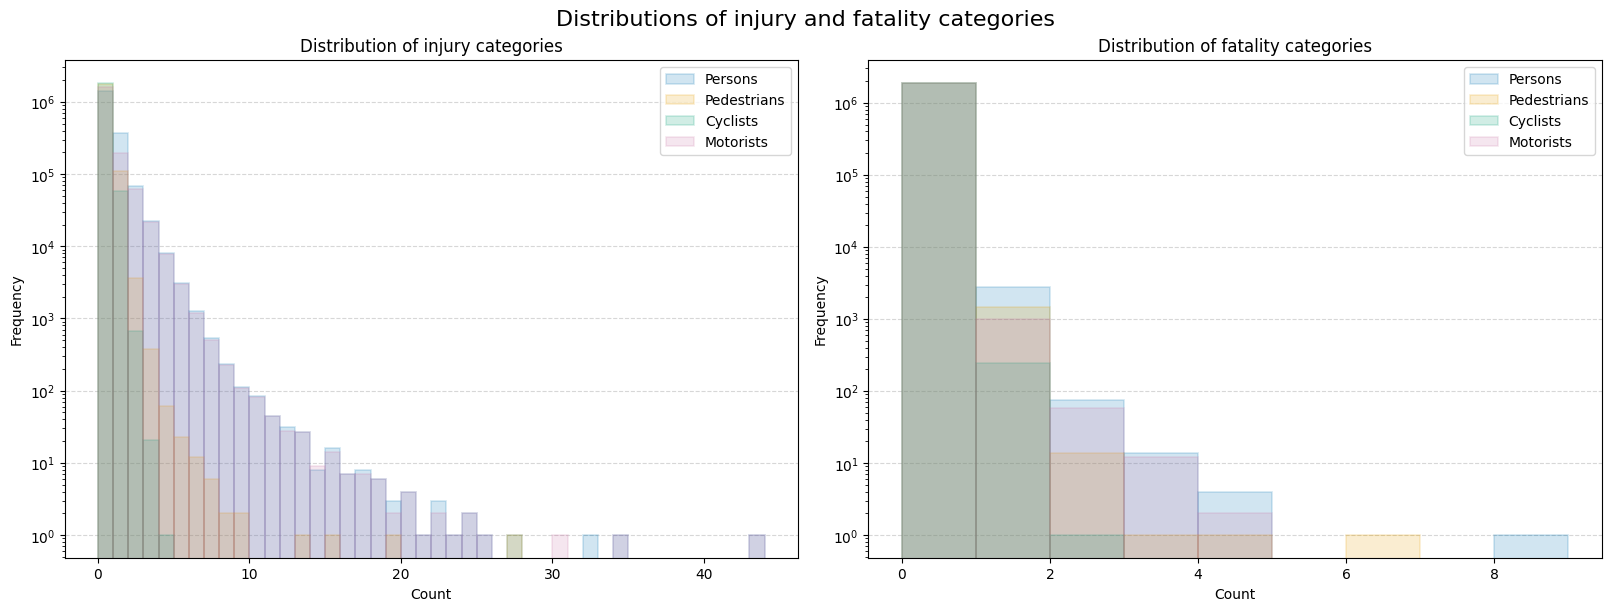

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

injury_labels = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

fatality_labels = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

# Higher-contrast palette than the default tab colors
colors = {
    "Persons": "#0072B2",       # blue
    "Pedestrians": "#E69F00",   # orange
    "Cyclists": "#009E73",      # green
    "Motorists": "#CC79A7",     # magenta
}

for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# ---------- injuries ----------
inj_max = int(df_clean[injured_cols].max().max())
inj_bins = np.arange(0, inj_max + 2)

for col in injured_cols:
    vals = df_clean[col].dropna().astype(int)
    label = injury_labels[col]
    color = colors[label]

    # filled histogram
    counts, bins, _ = axes[0].hist(
        vals,
        bins=inj_bins,
        alpha=0.18,
        color=color,
        edgecolor=color,
        linewidth=1.2,
        label=label
    )

    # frequency polygon on top
    #mids = 0.5 * (bins[:-1] + bins[1:])
    #axes[0].plot(
    #    mids,
    #    counts,
    #    color=color,
    #    linewidth=2.0
    #)

axes[0].set_title("Distribution of injury categories")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.5)
axes[0].set_axisbelow(True)
axes[0].legend(frameon=True)

# ---------- fatalities ----------
kill_max = int(df_clean[killed_cols].max().max())
kill_bins = np.arange(0, kill_max + 2)

for col in killed_cols:
    vals = df_clean[col].dropna().astype(int)
    label = fatality_labels[col]
    color = colors[label]

    counts, bins, _ = axes[1].hist(
        vals,
        bins=kill_bins,
        alpha=0.18,
        color=color,
        edgecolor=color,
        linewidth=1.2,
        label=label
    )

    #mids = 0.5 * (bins[:-1] + bins[1:])
    #axes[1].plot(
    #    mids,
    #    counts,
    #    color=color,
    #    linewidth=2.0
    #)

axes[1].set_title("Distribution of fatality categories")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.5)
axes[1].set_axisbelow(True)
axes[1].legend(frameon=True)

fig.suptitle("Distributions of injury and fatality categories", fontsize=16)
plt.show()

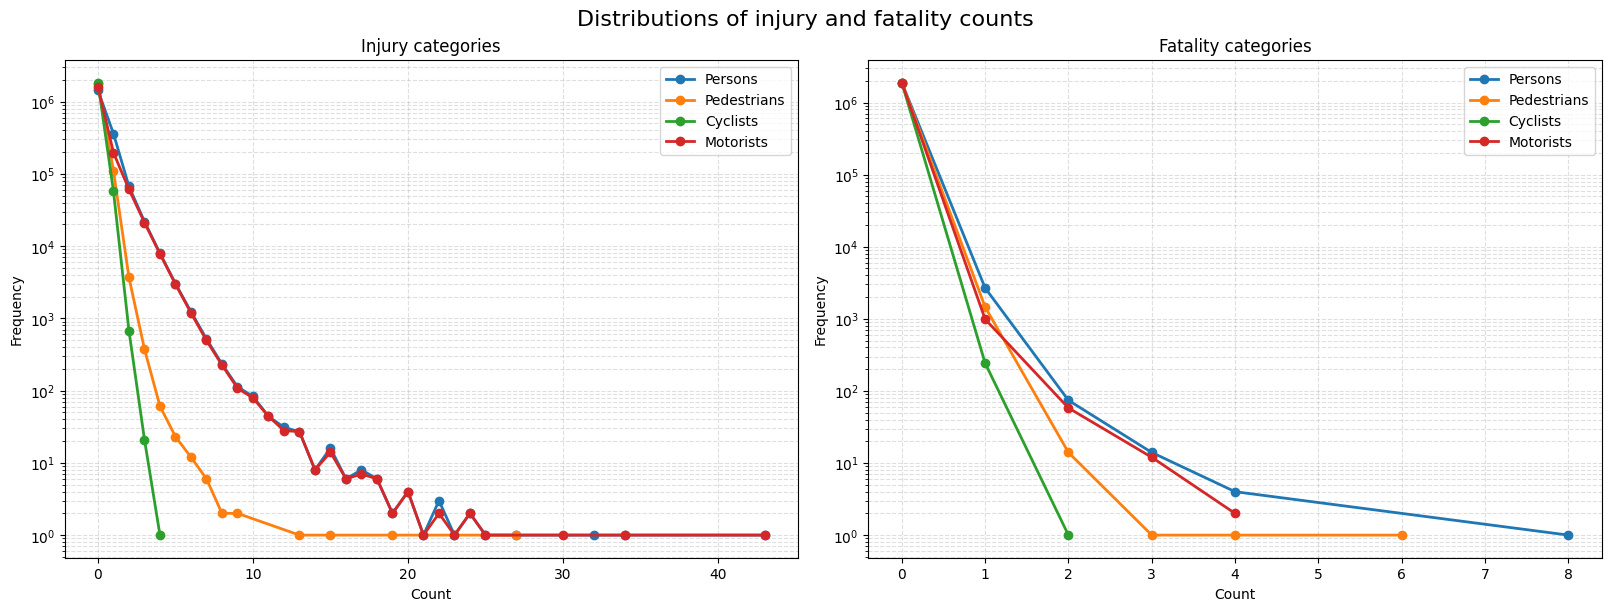

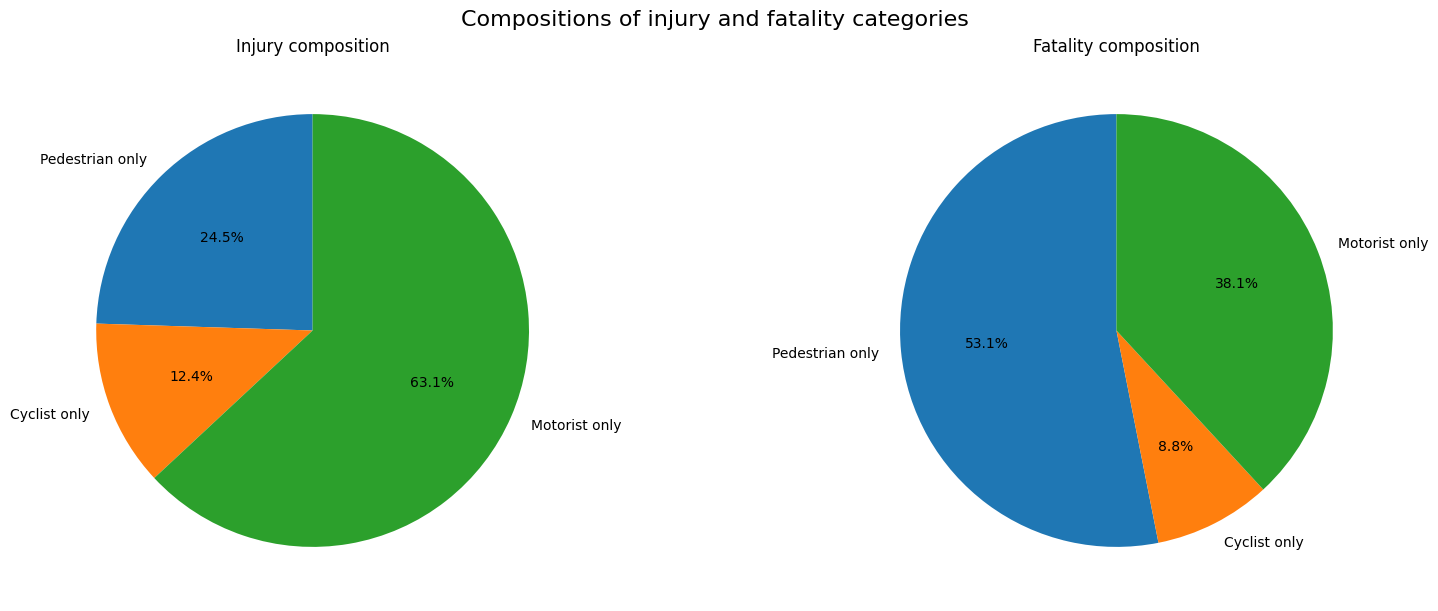

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

labels_inj = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

labels_kil = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# ==================================================
# Figure 1: line plots (1x2)
# ==================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# injuries
for col in injured_cols:
    freq = df_clean[col].dropna().astype(int).value_counts().sort_index()
    axes1[0].plot(freq.index, freq.values, marker="o", linewidth=2, label=labels_inj[col])

axes1[0].set_title("Injury categories")
axes1[0].set_xlabel("Count")
axes1[0].set_ylabel("Frequency")
axes1[0].set_yscale("log")
axes1[0].grid(True, which="both", linestyle="--", alpha=0.4)
axes1[0].legend()

# fatalities
for col in killed_cols:
    freq = df_clean[col].dropna().astype(int).value_counts().sort_index()
    axes1[1].plot(freq.index, freq.values, marker="o", linewidth=2, label=labels_kil[col])

axes1[1].set_title("Fatality categories")
axes1[1].set_xlabel("Count")
axes1[1].set_ylabel("Frequency")
axes1[1].set_yscale("log")
axes1[1].grid(True, which="both", linestyle="--", alpha=0.4)
axes1[1].legend()

fig1.suptitle("Distributions of injury and fatality counts", fontsize=16)
plt.show()

# ==================================================
# Figure 2: pie charts (1x2)
# ==================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# injury pie
ped_inj = df_clean["NUMBER OF PEDESTRIANS INJURED"].fillna(0) > 0
cyc_inj = df_clean["NUMBER OF CYCLIST INJURED"].fillna(0) > 0
mot_inj = df_clean["NUMBER OF MOTORIST INJURED"].fillna(0) > 0

inj_pie_counts = pd.Series({
    "Pedestrian only": ((ped_inj) & (~cyc_inj) & (~mot_inj)).sum(),
    "Cyclist only": ((~ped_inj) & (cyc_inj) & (~mot_inj)).sum(),
    "Motorist only": ((~ped_inj) & (~cyc_inj) & (mot_inj)).sum(),
})

inj_pie_counts = inj_pie_counts[inj_pie_counts > 0]

axes2[0].pie(
    inj_pie_counts.values,
    labels=inj_pie_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes2[0].set_title("Injury composition")

# fatality pie
ped_kil = df_clean["NUMBER OF PEDESTRIANS KILLED"].fillna(0) > 0
cyc_kil = df_clean["NUMBER OF CYCLIST KILLED"].fillna(0) > 0
mot_kil = df_clean["NUMBER OF MOTORIST KILLED"].fillna(0) > 0

kil_pie_counts = pd.Series({
    "Pedestrian only": ((ped_kil) & (~cyc_kil) & (~mot_kil)).sum(),
    "Cyclist only": ((~ped_kil) & (cyc_kil) & (~mot_kil)).sum(),
    "Motorist only": ((~ped_kil) & (~cyc_kil) & (mot_kil)).sum(),
})

kil_pie_counts = kil_pie_counts[kil_pie_counts > 0]

axes2[1].pie(
    kil_pie_counts.values,
    labels=kil_pie_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes2[1].set_title("Fatality composition")

fig2.suptitle("Compositions of injury and fatality categories", fontsize=16)
plt.show()

## TODO:

Look at temporal information on crashes between the different categories. After that we go heatmaps and maps.

From chat answer it seems that number of person should be the sum so i have to decide if i want to remove it. Medium source to back it up also : https://joycegemcanete.medium.com/simple-analysis-of-the-new-york-motor-vehicle-collision-dataset-c6f883646560

In [29]:
df_clean["BOROUGH"].unique()

array(['BROOKLYN', 'Unknown', 'BRONX', 'MANHATTAN', 'QUEENS',
       'STATEN ISLAND'], dtype=object)

Lets look at P(injury_category | contributing factor)

In [38]:
df_factor = df_clean.copy()

# Clean factor column
df_factor["CONTRIBUTING FACTOR VEHICLE 1"] = (
    df_factor["CONTRIBUTING FACTOR VEHICLE 1"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
)

# Numeric conversion
cols_needed = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

for col in cols_needed:
    df_factor[col] = pd.to_numeric(df_factor[col], errors="coerce").fillna(0)

# Binary indicators
df_factor["Persons injured"] = (df_factor["NUMBER OF PERSONS INJURED"] > 0).astype(int)
df_factor["Pedestrians injured"] = (df_factor["NUMBER OF PEDESTRIANS INJURED"] > 0).astype(int)
df_factor["Cyclists injured"] = (df_factor["NUMBER OF CYCLIST INJURED"] > 0).astype(int)
df_factor["Motorists injured"] = (df_factor["NUMBER OF MOTORIST INJURED"] > 0).astype(int)

df_factor["Persons killed"] = (df_factor["NUMBER OF PERSONS KILLED"] > 0).astype(int)
df_factor["Pedestrians killed"] = (df_factor["NUMBER OF PEDESTRIANS KILLED"] > 0).astype(int)
df_factor["Cyclists killed"] = (df_factor["NUMBER OF CYCLIST KILLED"] > 0).astype(int)
df_factor["Motorists killed"] = (df_factor["NUMBER OF MOTORIST KILLED"] > 0).astype(int)

# Keep the most common factors so the plot stays readable
top_factors = df_factor["CONTRIBUTING FACTOR VEHICLE 1"].value_counts().head(20).index
df_factor_top = df_factor[df_factor["CONTRIBUTING FACTOR VEHICLE 1"].isin(top_factors)].copy()

injury_cols = [
    "Persons injured",
    "Pedestrians injured",
    "Cyclists injured",
    "Motorists injured",
]

fatality_cols = [
    "Persons killed",
    "Pedestrians killed",
    "Cyclists killed",
    "Motorists killed",
]

# Conditional percentages: mean of indicator within factor group
injury_heat = (
    df_factor_top.groupby("CONTRIBUTING FACTOR VEHICLE 1")[injury_cols]
    .mean()
    .mul(100)
)

fatality_heat = (
    df_factor_top.groupby("CONTRIBUTING FACTOR VEHICLE 1")[fatality_cols]
    .mean()
    .mul(100)
)

# Order factors by overall injury severity for readability
factor_order = injury_heat["Persons injured"].sort_values().index
injury_heat = injury_heat.loc[factor_order]
fatality_heat = fatality_heat.loc[factor_order]

# Plot

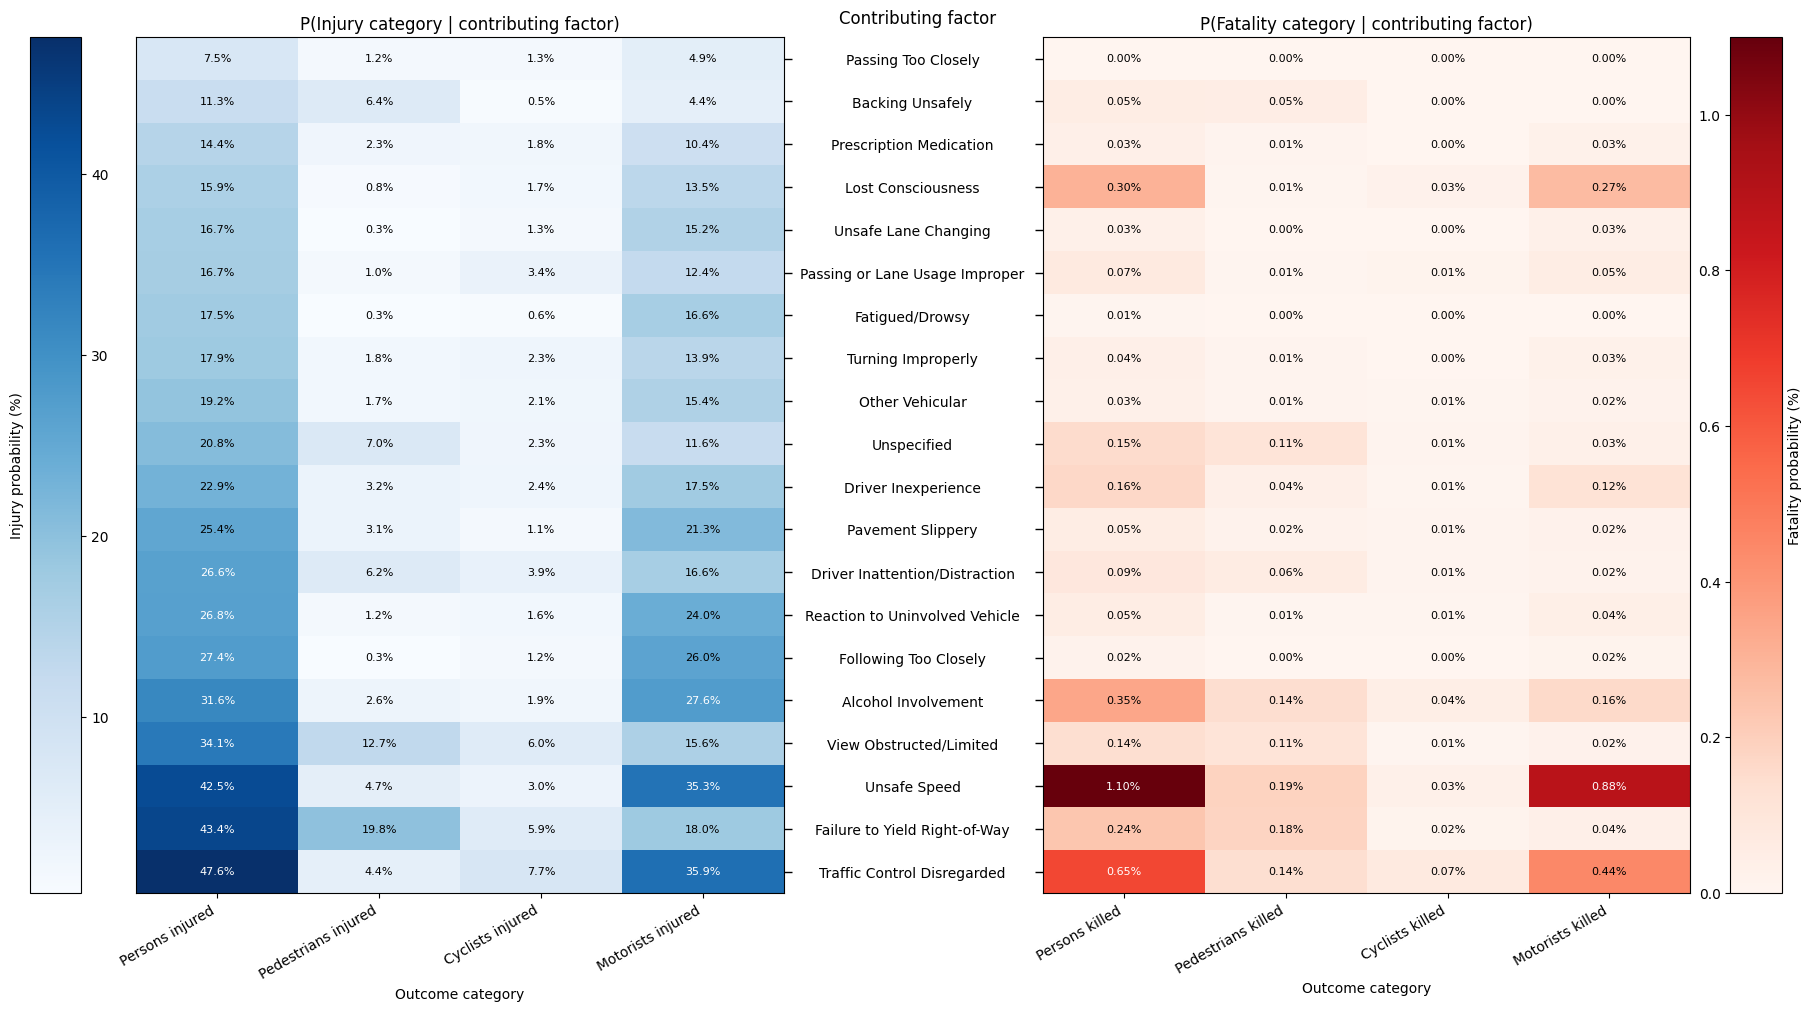

In [39]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

n_rows = len(injury_heat.index)

fig = plt.figure(figsize=(18, 10), constrained_layout=True)
gs = GridSpec(
    1, 5,
    figure=fig,
    width_ratios=[0.08, 1, 0.015, 1, 0.08]   # narrow middle column
)

cax_left = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax_mid = fig.add_subplot(gs[0, 2])
ax2 = fig.add_subplot(gs[0, 3], sharey=ax1)
cax_right = fig.add_subplot(gs[0, 4])

# ---------------- Injury heatmap ----------------
im1 = ax1.imshow(
    injury_heat.values,
    aspect="auto",
    cmap="Blues"
)

ax1.set_title("P(Injury category | contributing factor)")
ax1.set_xlabel("Outcome category")
ax1.set_xticks(range(len(injury_cols)))
ax1.set_xticklabels(injury_cols, rotation=30, ha="right")

ax1.set_yticks(range(n_rows))
ax1.set_yticklabels([])
ax1.yaxis.tick_right()
ax1.tick_params(axis="y", right=True, left=False, length=6, width=1)

for i in range(injury_heat.shape[0]):
    for j in range(injury_heat.shape[1]):
        val = injury_heat.iat[i, j]
        ax1.text(
            j, i, f"{val:.1f}%",
            ha="center", va="center",
            color="white" if val > injury_heat.values.max() * 0.55 else "black",
            fontsize=8
        )

# ---------------- Middle label axis ----------------
ax_mid.set_xlim(0, 1)
ax_mid.set_ylim(n_rows - 0.5, -0.5)
ax_mid.set_xticks([])
ax_mid.set_yticks(range(n_rows))
ax_mid.set_yticklabels(injury_heat.index)

# center the factor labels
for lbl in ax_mid.get_yticklabels():
    lbl.set_horizontalalignment("center")

ax_mid.tick_params(axis="y", left=False, right=False, length=0, pad=0)
for spine in ax_mid.spines.values():
    spine.set_visible(False)

ax_mid.set_title("Contributing factor", pad=10, loc="center")

# ---------------- Fatality heatmap ----------------
im2 = ax2.imshow(
    fatality_heat.values,
    aspect="auto",
    cmap="Reds"
)

ax2.set_title("P(Fatality category | contributing factor)")
ax2.set_xlabel("Outcome category")
ax2.set_xticks(range(len(fatality_cols)))
ax2.set_xticklabels(fatality_cols, rotation=30, ha="right")

ax2.set_yticks(range(n_rows))
ax2.set_yticklabels([])
ax2.yaxis.tick_left()
ax2.tick_params(axis="y", left=True, right=False, length=6, width=1)

for i in range(fatality_heat.shape[0]):
    for j in range(fatality_heat.shape[1]):
        val = fatality_heat.iat[i, j]
        ax2.text(
            j, i, f"{val:.2f}%",
            ha="center", va="center",
            color="white" if val > fatality_heat.values.max() * 0.55 else "black",
            fontsize=8
        )

# ---------------- Colorbars ----------------
cbar1 = fig.colorbar(im1, cax=cax_left)
cbar1.set_label("Injury probability (%)")
cbar1.ax.yaxis.set_label_position("left")

cbar2 = fig.colorbar(im2, cax=cax_right)
cbar2.set_label("Fatality probability (%)")
cbar2.ax.yaxis.set_ticks_position("left")

plt.show()

Each cell in the heatmaps represents a **conditional probability** computed from the crash-level data. Since each row in the dataset corresponds to a single crash event, we first define a binary indicator for whether a given outcome occurred in that crash. For example, for *pedestrian injury*, the indicator equals 1 if `NUMBER OF PEDESTRIANS INJURED > 0` and 0 otherwise. We then group crashes by `CONTRIBUTING FACTOR VEHICLE 1` and take the mean of that indicator within each factor group. This gives the conditional probability  
\[
P(\text{outcome category} \mid \text{contributing factor})
\]
that is, the probability that a crash involves a given injury or fatality category **given** that the crash was assigned a particular primary contributing factor. Finally, these probabilities are multiplied by 100 so that the heatmap values are shown as percentages. For instance, a value of 32.4 in the *Persons injured* column for a given factor means that **32.4% of crashes with that contributing factor involved at least one injured person**.

## Important notes on interpreting the conditional probability heatmaps

Each cell in the heatmaps represents a **conditional probability** of the form

\[
P(\text{outcome category} \mid \text{contributing factor})
\]

This means that, for a given contributing factor, we calculate the fraction of crashes in that factor group that resulted in a specific injury or fatality outcome.

### How each probability is calculated

For each crash, we first create a binary indicator for whether an outcome occurred:

- `1` if the crash involved that outcome
- `0` otherwise

For example:

- `Pedestrians killed = 1` if `NUMBER OF PEDESTRIANS KILLED > 0`
- `Pedestrians killed = 0` otherwise

Then, for each value of `CONTRIBUTING FACTOR VEHICLE 1`, we take the mean of that binary indicator within the group. This gives:

\[
P(\text{outcome category} \mid \text{contributing factor})
=
\frac{\#(\text{crashes with factor and outcome})}{\#(\text{crashes with factor})}
\]

The values are then multiplied by 100, so the heatmap displays **percentages**.

### What the denominator is

The denominator is **not** the total number of crashes in the entire dataset.

It is only the number of crashes within the relevant contributing-factor group.

So, for example:

\[
P(\text{Pedestrians killed} \mid \text{Unsafe speed})
=
\frac{\#(\text{crashes with Unsafe speed and at least one pedestrian killed})}{\#(\text{all crashes with Unsafe speed})}
\]

If there is 1 such crash and 500 crashes in total with `Unsafe speed`, then the value is:

\[
\frac{1}{500} = 0.002 = 0.2\%
\]

This is **not** the same as dividing by the total number of rows in the dataset.

### Why the fatality probabilities are so low

Fatality probabilities are generally much lower than injury probabilities because fatalities are much rarer crash outcomes.

Even within a specific contributing-factor group, only a small share of crashes will involve a death. Therefore:

\[
P(\text{fatality category} \mid \text{factor})
\]

is usually much smaller than:

\[
P(\text{injury category} \mid \text{factor})
\]

This does **not** mean the plot is incorrectly normalized. It simply reflects that fatalities are rare relative to injuries.

### Why rows do not sum to 100%

The probabilities across a row do **not** sum to 100%, and they are not supposed to.

This is because the outcome categories are **not mutually exclusive**. A single crash can contribute to multiple categories at the same time. For example, one crash could involve:

- at least one injured person
- at least one injured pedestrian
- at least one injured motorist

That same crash would count in several columns simultaneously.

In addition, `Persons injured` and `Persons killed` are broad totals, while the pedestrian, cyclist, and motorist columns are subgroup indicators. These overlap by construction.

Therefore, the values in a row are separate conditional probabilities, not parts of a distribution that must sum to 1.

### What a cell should be interpreted as

Each cell answers the following question:

> Among crashes with this contributing factor, how often did this specific type of harm occur?

For example, if a cell shows `32.4%` in the `Persons injured` column for a given factor, that means:

> 32.4% of crashes with that contributing factor involved at least one injured person.

### What the heatmap is **not** showing

The heatmap is **not** showing the fraction of all crashes in the dataset with a given factor-outcome combination. That would be a different quantity:

\[
\frac{\#(\text{crashes with factor and outcome})}{\#(\text{all crashes})}
\]

This would be a **joint share of the full dataset**, not a conditional probability.

### Summary interpretation

A good summary interpretation is:

> Each heatmap cell shows the percentage of crashes with a given primary contributing factor that involved at least one injury or fatality in the specified category. These are conditional probabilities computed within each factor group, so values do not sum across rows because the outcome categories overlap.

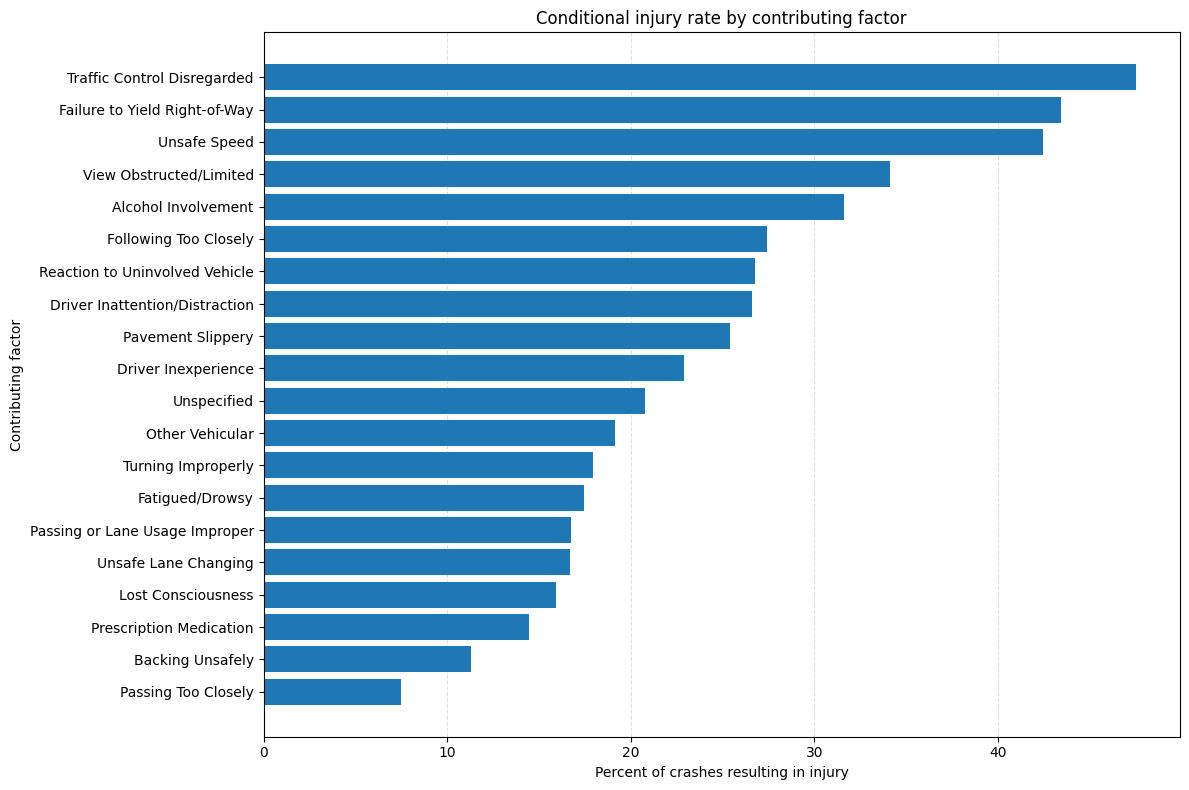

In [40]:
factor_injury_pct = (
    df_factor_top.groupby("CONTRIBUTING FACTOR VEHICLE 1")["Persons injured"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(12, 8))
plt.barh(factor_injury_pct.index, factor_injury_pct.values)
plt.xlabel("Percent of crashes resulting in injury")
plt.ylabel("Contributing factor")
plt.title("Conditional injury rate by contributing factor")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

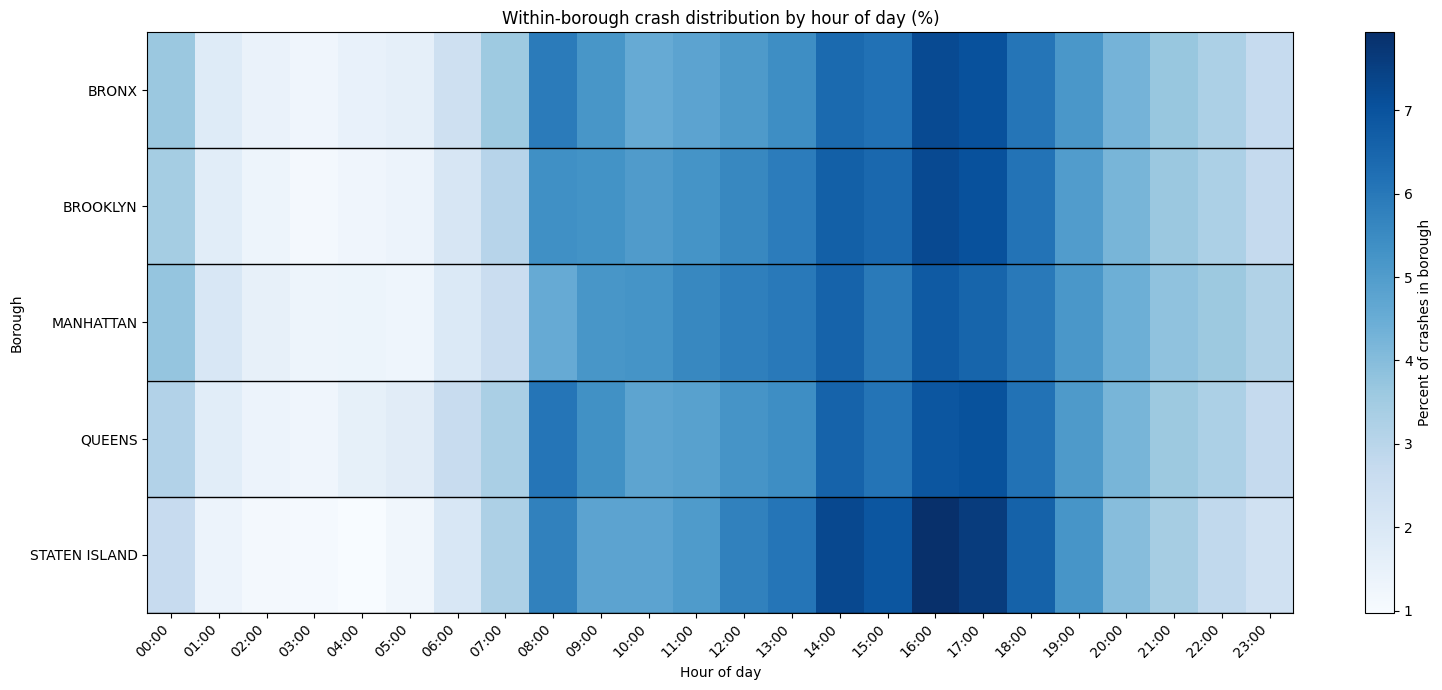

In [19]:
# Normalize each borough row to percentages

df_clean["HOUR"] = df_clean["CRASH DATETIME"].dt.hour
df_clean["HOUR"] = df_clean["HOUR"].astype(int)

boro_order = ["Unknown","BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND", ]
existing_boros = [b for b in boro_order if b in df_clean["BOROUGH"].unique()]
remaining_boros = [b for b in sorted(df_clean["BOROUGH"].unique()) if b not in existing_boros]
boro_order = existing_boros + remaining_boros

heatmap_data = (
    df_clean.groupby(["BOROUGH", "HOUR"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=boro_order, columns=range(24), fill_value=0)
)

heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 7))

im = ax.imshow(
    heatmap_pct.values,
    aspect="auto",
    cmap="Blues",
    origin="upper"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_pct.index)))
ax.set_yticklabels(heatmap_pct.index)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Borough")
ax.set_title("Within-borough crash distribution by hour of day (%)")
for y in np.arange(0.5, len(heatmap_pct.index), 1):
    ax.axhline(y=y, color="black", linewidth=1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percent of crashes in borough")

plt.tight_layout()
plt.show()

I Probably need some by borough visualization on how the different crash/injury distribute by borough?

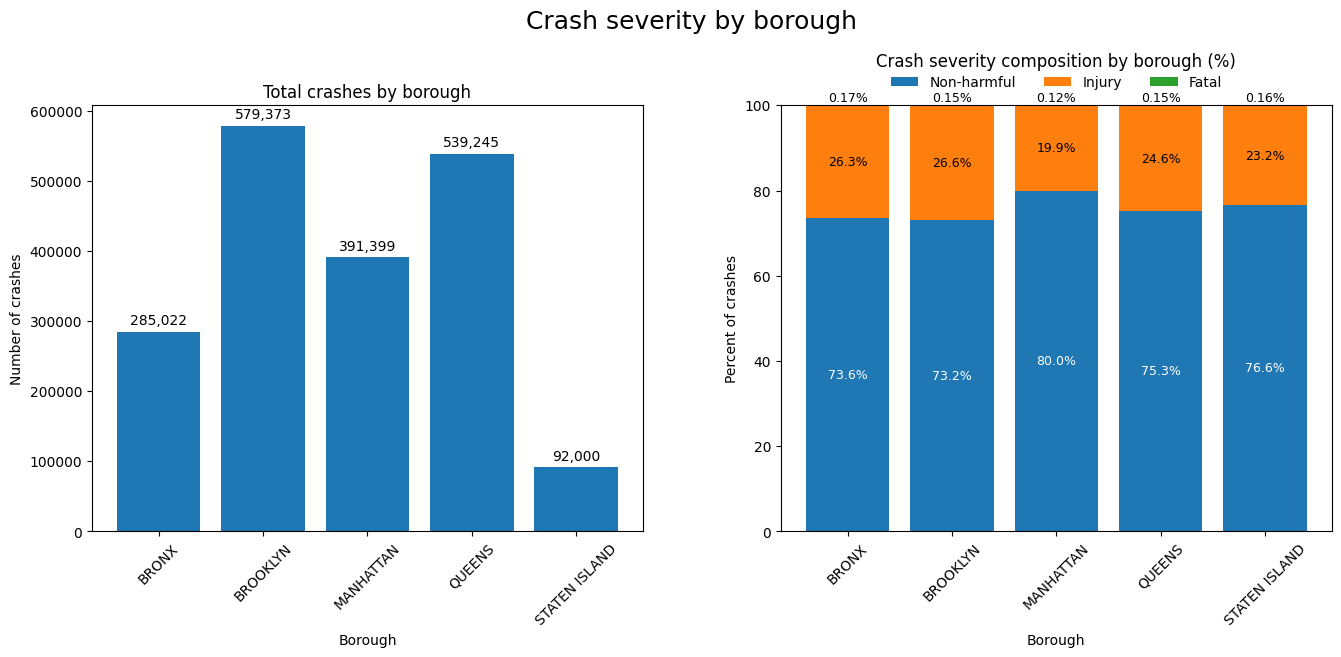

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_plot = df_clean.copy()

# -----------------------------
# 1) Clean borough names
# -----------------------------
df_plot["BOROUGH"] = (
    df_plot["BOROUGH"]
    .fillna("UNKNOWN")
    .astype(str)
    .str.strip()
    .replace("", "UNKNOWN")
    .str.upper()
)

boro_order = ["UNKNOWN", "BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
existing_boros = [b for b in boro_order if b in df_plot["BOROUGH"].unique()]
remaining_boros = [b for b in sorted(df_plot["BOROUGH"].unique()) if b not in existing_boros]
boro_order = existing_boros + remaining_boros

# Keep only boroughs you want to show
boro_order = [b for b in boro_order if b != "UNKNOWN"]

# -----------------------------
# 2) Define severity
# -----------------------------
df_plot["NUMBER OF PERSONS INJURED"] = pd.to_numeric(df_plot["NUMBER OF PERSONS INJURED"], errors="coerce").fillna(0)
df_plot["NUMBER OF PERSONS KILLED"] = pd.to_numeric(df_plot["NUMBER OF PERSONS KILLED"], errors="coerce").fillna(0)

df_plot["HAS_FATAL"] = df_plot["NUMBER OF PERSONS KILLED"] > 0
df_plot["HAS_INJURY"] = df_plot["NUMBER OF PERSONS INJURED"] > 0

df_plot["SEVERITY"] = np.select(
    [
        df_plot["HAS_FATAL"],
        (~df_plot["HAS_FATAL"]) & (df_plot["HAS_INJURY"])
    ],
    [
        "Fatal",
        "Injury"
    ],
    default="Non-harmful"
)

severity_order = ["Non-harmful", "Injury", "Fatal"]

# -----------------------------
# 3) Aggregate
# -----------------------------
total_crashes = (
    df_plot.groupby("BOROUGH")
    .size()
    .reindex(boro_order)
    .fillna(0)
)

severity_counts = (
    df_plot.groupby(["BOROUGH", "SEVERITY"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=boro_order, columns=severity_order, fill_value=0)
)

severity_pct = severity_counts.div(severity_counts.sum(axis=1), axis=0) * 100

# -----------------------------
# 4) Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(top=0.82, wspace=0.25)

# Overall figure title
fig.suptitle("Crash severity by borough", fontsize=18, y=0.98)

# -----------------------------
# Left panel: total crashes
# -----------------------------
bars = axes[0].bar(total_crashes.index, total_crashes.values)
axes[0].set_title("Total crashes by borough")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of crashes")
axes[0].tick_params(axis="x", rotation=45)

for i, v in enumerate(total_crashes.values):
    axes[0].text(
        i,
        v + total_crashes.max() * 0.01,
        f"{int(v):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# -----------------------------
# Right panel: severity composition
# -----------------------------
bottom = np.zeros(len(severity_pct))
colors = {
    "Non-harmful": "#1f77b4",
    "Injury": "#ff7f0e",
    "Fatal": "#2ca02c"
}

for sev in severity_order:
    axes[1].bar(
        severity_pct.index,
        severity_pct[sev].values,
        bottom=bottom,
        label=sev,
        color=colors[sev]
    )
    bottom += severity_pct[sev].values

axes[1].set_title("Crash severity composition by borough", pad=28)
#axes[1].set_xlabel("Borough")
axes[1].set_xlabel("")
axes[1].set_ylabel("Percent of crashes")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=45)

# Legend below right subplot title
axes[1].legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=3,
    frameon=False
)

# -----------------------------
# Segment labels for all parts
# -----------------------------
non_vals = severity_pct["Non-harmful"].values
inj_vals = severity_pct["Injury"].values
fatal_vals = severity_pct["Fatal"].values

for i in range(len(severity_pct)):
    # Non-harmful label centered in blue bar
    axes[1].text(
        i,
        non_vals[i] / 2,
        f"{non_vals[i]:.1f}%",
        ha="center",
        va="center",
        fontsize=9,
        color="white"
    )

    # Injury label centered in orange segment
    axes[1].text(
        i,
        non_vals[i] + inj_vals[i] / 2,
        f"{inj_vals[i]:.1f}%",
        ha="center",
        va="center",
        fontsize=9,
        color="black"
    )

    # Fatal label near top; tiny so place just above stack
    axes[1].text(
        i,
        100 + 0.3,
        f"{fatal_vals[i]:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
        clip_on=False
    )

plt.show()

In [25]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

df_plot = df_clean.copy()

# -----------------------------
# 1) Clean borough names
# -----------------------------
df_plot["BOROUGH"] = (
    df_plot["BOROUGH"]
    .fillna("UNKNOWN")
    .astype(str)    
    .str.strip()
    .replace("", "UNKNOWN")
    .str.upper()
)

boro_order = ["UNKNOWN", "BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
existing_boros = [b for b in boro_order if b in df_plot["BOROUGH"].unique()]
remaining_boros = [b for b in sorted(df_plot["BOROUGH"].unique()) if b not in existing_boros]
boro_order = existing_boros + remaining_boros

victim_order = ["Pedestrian", "Cyclist", "Motorist"]

# -----------------------------
# 2) Raw casualty columns
# -----------------------------
casualty_cols = {
    "NUMBER OF PEDESTRIANS INJURED": ("Injured", "Pedestrian"),
    "NUMBER OF CYCLIST INJURED": ("Injured", "Cyclist"),
    "NUMBER OF MOTORIST INJURED": ("Injured", "Motorist"),
    "NUMBER OF PEDESTRIANS KILLED": ("Killed", "Pedestrian"),
    "NUMBER OF CYCLIST KILLED": ("Killed", "Cyclist"),
    "NUMBER OF MOTORIST KILLED": ("Killed", "Motorist"),
}

for col in casualty_cols:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce").fillna(0).astype(int)

# -----------------------------
# 3) Melt raw data
# -----------------------------
long_df = df_plot.melt(
    id_vars=["COLLISION_ID", "BOROUGH"],
    value_vars=list(casualty_cols.keys()),
    var_name="RAW_CATEGORY",
    value_name="COUNT"
)

long_df = long_df[long_df["COUNT"] > 0].copy()
long_df["OUTCOME"] = long_df["RAW_CATEGORY"].map(lambda x: casualty_cols[x][0])
long_df["VICTIM_TYPE"] = long_df["RAW_CATEGORY"].map(lambda x: casualty_cols[x][1])

# Expand to raw harmed-person-category occurrences
long_df = long_df.loc[long_df.index.repeat(long_df["COUNT"])].reset_index(drop=True)

# -----------------------------
# 4) Borough total crashes
# -----------------------------
borough_total_crashes = (
    df_plot.groupby("BOROUGH")["COLLISION_ID"]
    .nunique()
    .reindex(boro_order)
    .fillna(0)
)

def compute_node_positions(values, top=0.02, bottom=0.98, gap=0.02, min_height=0.035):
    """
    Compute non-overlapping y centers for Sankey nodes based on node values.
    Gives larger nodes more room.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)

    if values.sum() == 0:
        return np.linspace(top, bottom, n)

    usable = (bottom - top) - gap * (n - 1)
    raw_heights = values / values.sum() * usable
    heights = np.maximum(raw_heights, min_height)

    # Rescale if minimum heights + gaps exceed available space
    total_needed = heights.sum() + gap * (n - 1)
    if total_needed > (bottom - top):
        scale = ((bottom - top) - gap * (n - 1)) / heights.sum()
        heights = heights * scale

    ys = []
    current = top
    for h in heights:
        ys.append(current + h / 2)
        current += h + gap

    return ys

def build_sankey_trace(df_sub, outcome_name, domain_x, link_color, node_color):
    # Borough -> victim flow counts from raw expanded data
    flow_counts = (
        df_sub.groupby(["BOROUGH", "VICTIM_TYPE"])
        .size()
        .reindex(
            pd.MultiIndex.from_product([boro_order, victim_order], names=["BOROUGH", "VICTIM_TYPE"]),
            fill_value=0
        )
        .reset_index(name="COUNT")
    )

    flow_counts = flow_counts[flow_counts["COUNT"] > 0].copy()

    borough_outcome_counts = (
        flow_counts.groupby("BOROUGH")["COUNT"]
        .sum()
        .reindex(boro_order)
        .fillna(0)
    )

    victim_totals = (
        flow_counts.groupby("VICTIM_TYPE")["COUNT"]
        .sum()
        .reindex(victim_order)
        .fillna(0)
    )

    panel_total = victim_totals.sum()

    # Borough victim breakdown for hover
    borough_victim_breakdown = (
        flow_counts.pivot(index="BOROUGH", columns="VICTIM_TYPE", values="COUNT")
        .reindex(index=boro_order, columns=victim_order)
        .fillna(0)
    )

    labels = boro_order + victim_order
    node_index = {label: i for i, label in enumerate(labels)}

    sources = flow_counts["BOROUGH"].map(node_index).tolist()
    targets = flow_counts["VICTIM_TYPE"].map(lambda x: node_index[x]).tolist()
    values = flow_counts["COUNT"].tolist()

    # Link hover data
    # [count, share within borough outcome total, count per 100 crashes in borough]
    link_customdata = []
    for _, row in flow_counts.iterrows():
        borough = row["BOROUGH"]
        count = row["COUNT"]
        borough_outcome_total = borough_outcome_counts.loc[borough]
        borough_crashes = borough_total_crashes.loc[borough]

        share_within_borough_outcome = count / borough_outcome_total if borough_outcome_total > 0 else 0
        per_100_crashes = (count / borough_crashes * 100) if borough_crashes > 0 else 0

        link_customdata.append([
            int(count),
            share_within_borough_outcome,
            per_100_crashes
        ])

    # Borough node customdata
    # [total crashes, outcome total, share of panel, outcome per 100 crashes,
    #  ped count, cyc count, mot count,
    #  ped share in borough, cyc share in borough, mot share in borough]
    borough_node_customdata = []
    for b in boro_order:
        total_crashes = borough_total_crashes.loc[b]
        outcome_total = borough_outcome_counts.loc[b]
        share_panel = outcome_total / panel_total if panel_total > 0 else 0
        per_100 = (outcome_total / total_crashes * 100) if total_crashes > 0 else 0

        ped = borough_victim_breakdown.loc[b, "Pedestrian"]
        cyc = borough_victim_breakdown.loc[b, "Cyclist"]
        mot = borough_victim_breakdown.loc[b, "Motorist"]

        ped_share = ped / outcome_total if outcome_total > 0 else 0
        cyc_share = cyc / outcome_total if outcome_total > 0 else 0
        mot_share = mot / outcome_total if outcome_total > 0 else 0

        borough_node_customdata.append([
            int(total_crashes),
            int(outcome_total),
            share_panel,
            per_100,
            int(ped),
            int(cyc),
            int(mot),
            ped_share,
            cyc_share,
            mot_share
        ])

    # Victim node customdata
    # [total victim count, share of panel, top borough name, top borough count, top borough share]
    victim_node_customdata = []
    for v in victim_order:
        total_v = victim_totals.loc[v]
        share_panel = total_v / panel_total if panel_total > 0 else 0

        by_borough = (
            flow_counts.loc[flow_counts["VICTIM_TYPE"] == v, ["BOROUGH", "COUNT"]]
            .set_index("BOROUGH")["COUNT"]
            .reindex(boro_order)
            .fillna(0)
        )

        top_borough = by_borough.idxmax() if len(by_borough) > 0 else "N/A"
        top_borough_count = by_borough.max() if len(by_borough) > 0 else 0
        top_borough_share = top_borough_count / total_v if total_v > 0 else 0

        victim_node_customdata.append([
            int(total_v),
            share_panel,
            str(top_borough),
            int(top_borough_count),
            top_borough_share
        ])

    node_customdata = borough_node_customdata + victim_node_customdata

    # Better node positions based on actual sizes
    borough_y = compute_node_positions(
        borough_outcome_counts.values,
        top=0.03,
        bottom=0.97,
        gap=0.018,
        min_height=0.045
    )

    victim_y = compute_node_positions(
        victim_totals.values,
        top=0.08,
        bottom=0.92,
        gap=0.14,
        min_height=0.16
    )

    # manual tweak for Cyclist
    victim_y[1] -= 0.04

    node_x = [0.03] * len(boro_order) + [0.97] * len(victim_order)
    node_y = borough_y + victim_y

    trace = go.Sankey(
        domain={"x": domain_x, "y": [0.0, 1.0]},
        arrangement="fixed",
        node=dict(
            pad=22,
            thickness=18,
            line=dict(color="rgba(80,80,80,0.6)", width=0.7),
            label=labels,
            color=[node_color] * len(labels),
            x=node_x,
            y=node_y,
            customdata=node_customdata,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=[link_color] * len(values),
            customdata=link_customdata,
            hovertemplate=(
                "<b>%{source.label} → %{target.label}</b><br>"
                "Count: %{customdata[0]:,}<br>"
                "Share of borough " + outcome_name.lower() + " count: %{customdata[1]:.1%}<br>"
                + outcome_name + " count per 100 crashes in borough: %{customdata[2]:.1f}"
                "<extra></extra>"
            )
        )
    )

    # Per-node hovertemplate
    borough_n = len(boro_order)
    node_hovertemplates = []
    for i, label in enumerate(labels):
        if i < borough_n:
            node_hovertemplates.append(
                "<b>%{label}</b><br>"
                "Total crashes in borough: %{customdata[0]:,}<br>"
                "Total " + outcome_name.lower() + " count: %{customdata[1]:,}<br>"
                "Share of " + outcome_name.lower() + " panel: %{customdata[2]:.1%}<br>"
                + outcome_name + " count per 100 crashes: %{customdata[3]:.1f}<br>"
                "<br>"
                "Pedestrian: %{customdata[4]:,} (%{customdata[7]:.1%})<br>"
                "Cyclist: %{customdata[5]:,} (%{customdata[8]:.1%})<br>"
                "Motorist: %{customdata[6]:,} (%{customdata[9]:.1%})"
                "<extra></extra>"
            )
        else:
            node_hovertemplates.append(
                "<b>%{label}</b><br>"
                "Total count in panel: %{customdata[0]:,}<br>"
                "Share of panel: %{customdata[1]:.1%}<br>"
                "Top borough: %{customdata[2]}<br>"
                "Top borough count: %{customdata[3]:,}<br>"
                "Top borough share of this victim type: %{customdata[4]:.1%}"
                "<extra></extra>"
            )

    trace.node.hovertemplate = node_hovertemplates

    return trace, panel_total

inj_df = long_df[long_df["OUTCOME"] == "Injured"].copy()
kil_df = long_df[long_df["OUTCOME"] == "Killed"].copy()

inj_trace, inj_total = build_sankey_trace(
    inj_df,
    outcome_name="Injured",
    domain_x=[0.00, 0.46],
    link_color="rgba(76,120,168,0.45)",
    node_color="rgba(76,120,168,0.88)"
)

kil_trace, kil_total = build_sankey_trace(
    kil_df,
    outcome_name="Killed",
    domain_x=[0.54, 1.00],
    link_color="rgba(228,87,86,0.45)",
    node_color="rgba(228,87,86,0.88)"
)

fig = go.Figure(data=[inj_trace, kil_trace])

fig.update_layout(
    title=dict(
        text="Crash harm flows by borough",
        x=0.5,
        xanchor="center"
    ),
    width=1350,
    height=700,
    margin=dict(l=40, r=40, t=110, b=40),
    font=dict(size=12),
    annotations=[
        dict(
            text=f"<b>Injured</b><br>n = {inj_total:,}",
            x=0.23, y=1.03,
            xref="paper", yref="paper",
            xanchor="center", yanchor="bottom",
            align="center",
            showarrow=False,
            font=dict(size=16)
        ),
        dict(
            text=f"<b>Killed</b><br>n = {kil_total:,}",
            x=0.77, y=1.03,
            xref="paper", yref="paper",
            xanchor="center", yanchor="bottom",
            align="center",
            showarrow=False,
            font=dict(size=16)
        )
    ]
)

fig.show()

C:\Users\magnu\AppData\Local\Temp\ipykernel_23748\1970389375.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cat_order, rotation=20)


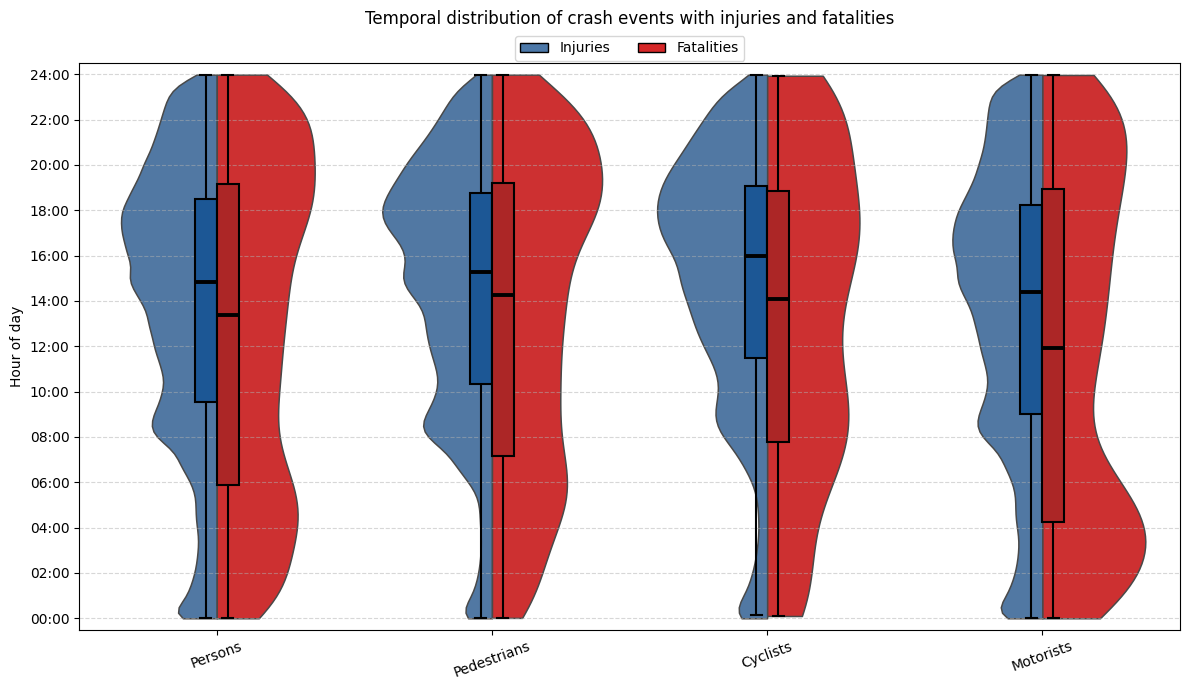

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

# -----------------------------------
# 1) Prepare time variable
# -----------------------------------
df_temp = df_clean.copy()

df_temp["hour_decimal"] = (
    df_temp["CRASH DATETIME"].dt.hour
    + df_temp["CRASH DATETIME"].dt.minute / 60
    + df_temp["CRASH DATETIME"].dt.second / 3600
)

# -----------------------------------
# 2) Numeric columns
# -----------------------------------
injury_cols = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

fatality_cols = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

for col in list(injury_cols.keys()) + list(fatality_cols.keys()):
    df_temp[col] = pd.to_numeric(df_temp[col], errors="coerce").fillna(0)

# -----------------------------------
# 3) Build long-form dataframe
# -----------------------------------
frames = []

for col, label in injury_cols.items():
    tmp = df_temp.loc[df_temp[col] > 0, ["hour_decimal"]].copy()
    tmp["Category"] = label
    tmp["Outcome"] = "Injury"
    frames.append(tmp)

for col, label in fatality_cols.items():
    tmp = df_temp.loc[df_temp[col] > 0, ["hour_decimal"]].copy()
    tmp["Category"] = label
    tmp["Outcome"] = "Fatality"
    frames.append(tmp)

plot_df = pd.concat(frames, ignore_index=True)

cat_order = ["Persons", "Pedestrians", "Cyclists", "Motorists"]
hue_order = ["Injury", "Fatality"]

palette = {
    "Injury": "#4C78A8",
    "Fatality": "#D62728"
}
palette_box = {
    "Injury": "#0856A9",
    "Fatality": "#C30F0F"
}

# -----------------------------------
# 4) Plot
# -----------------------------------
fig, ax = plt.subplots(figsize=(12, 7))

# Split violins
sns.violinplot(
    data=plot_df,
    x="Category",
    y="hour_decimal",
    hue="Outcome",
    order=cat_order,
    hue_order=hue_order,
    palette=palette,
    split=True,          # key change
    inner=None,
    cut=0,
    linewidth=1.1,
    saturation=0.9,
    ax=ax
)

# Narrow boxplots on top
sns.boxplot(
    data=plot_df,
    x="Category",
    y="hour_decimal",
    hue="Outcome",
    order=cat_order,
    hue_order=hue_order,
    dodge=True,
    width=0.16,          # slimmer boxes
    showfliers=False,
    palette={
        "Injury": to_rgba(palette_box["Injury"], 1.0),
        "Fatality": to_rgba(palette_box["Fatality"], 1.0)
    },
    boxprops={
        #"facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1.5,
        "zorder": 5
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.5,
        "zorder": 5
    },
    capprops={
        "color": "black",
        "linewidth": 1.5,
        "zorder": 5
    },
    medianprops={
        "color": "#000000",
        "linewidth": 2.8,
        "zorder": 6
    },
    ax=ax
)

# Remove seaborn auto legend
if ax.legend_ is not None:
    ax.legend_.remove()

# Custom legend under title
legend_handles = [
    Patch(facecolor=palette["Injury"], edgecolor="black", label="Injuries"),
    Patch(facecolor=palette["Fatality"], edgecolor="black", label="Fatalities")
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.06),
    ncol=2,
    frameon=True
)

# Labels and formatting
ax.set_title("Temporal distribution of crash events with injuries and fatalities", pad=28)
ax.set_xlabel("")
ax.set_ylabel("Hour of day")
ax.set_xticklabels(cat_order, rotation=20)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(-0.5, 24.5)

ticks = np.arange(0, 25, 2)
tick_labels = [f"{int(t):02d}:00" for t in ticks]
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)

plt.tight_layout()
plt.show()

Time to do maps and interactive visualizations

## First interactive visualization should be about 

In [56]:
df_clean["year"] = df_clean["CRASH DATETIME"].dt.year
df_clean["weekday"] = df_clean["CRASH DATETIME"].dt.day_name().str[:3]
df_clean["hour"] = df_clean["CRASH DATETIME"].dt.hour

## Map should be interactive on where the crimes happen:



In [ ]:
import pandas as pd
import folium
from folium.plugins import Fullscreen

# -----------------------------------
# 1) Copy and clean data
# -----------------------------------
df_map = df_clean.copy()

# Parse datetime
df_map["CRASH DATETIME"] = pd.to_datetime(df_map["CRASH DATETIME"], errors="coerce")

# Numeric coordinates
df_map["LATITUDE"] = pd.to_numeric(df_map["LATITUDE"], errors="coerce")
df_map["LONGITUDE"] = pd.to_numeric(df_map["LONGITUDE"], errors="coerce")

# Keep valid coordinates only
df_map = df_map.dropna(subset=["CRASH DATETIME", "LATITUDE", "LONGITUDE"]).copy()

# Optional: keep only plausible NYC bounds
df_map = df_map[
    df_map["LATITUDE"].between(40.4, 41.0) &
    df_map["LONGITUDE"].between(-74.3, -73.6)
].copy()

# Keep only 2013
df_2013 = df_map[df_map["CRASH DATETIME"].dt.year == 2013].copy()

print(f"Rows in 2013 with coordinates: {len(df_2013):,}")

# -----------------------------------
# 2) Build Folium map
# -----------------------------------
nyc_center = [40.7128, -74.0060]

m = folium.Map(
    location=nyc_center,
    zoom_start=10,
    tiles="CartoDB positron",
    control_scale=True
)

Fullscreen(position="topright").add_to(m)

# -----------------------------------
# 3) Add individual crash points
# -----------------------------------
for _, row in df_2013.iterrows():
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=1,
        stroke=False,
        fill=True,
        fill_opacity=0.08
    ).add_to(m)

# -----------------------------------
# 4) Save map
# -----------------------------------
m.save("nyc_crashes_2013_points.html")

m

In [18]:
df_clean.columns

Index(['BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'ON STREET NAME',
       'CROSS STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'COLLISION_ID', 'VEHICLE TYPE CODE 1',
       'VEHICLE TYPE CODE 2', 'CRASH DATETIME'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import folium
import geopandas as gpd

from folium.plugins import HeatMap, Fullscreen, MarkerCluster
from branca.colormap import linear

# --------------------------------------------------
# 1) Copy and clean crash data
# --------------------------------------------------
df_map = df_clean.copy()

# Coordinates
for col in ["LATITUDE", "LONGITUDE"]:
    df_map[col] = pd.to_numeric(df_map[col], errors="coerce")

df_map = df_map.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

# Numeric injury/fatality columns
count_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

for col in count_cols:
    df_map[col] = pd.to_numeric(df_map[col], errors="coerce").fillna(0)

# Datetime
if "CRASH DATETIME" in df_map.columns:
    df_map["CRASH DATETIME"] = pd.to_datetime(df_map["CRASH DATETIME"], errors="coerce")

# Borough cleaning
df_map["BOROUGH"] = (
    df_map["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.title()
)

df_map = df_map[
    ~df_map["BOROUGH"].str.lower().isin(["unspecified", "unknown", ""])
].copy()

# Street cleaning
for col in ["ON STREET NAME", "CROSS STREET NAME"]:
    df_map[col] = (
        df_map[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

# Binary flags
df_map["any_injury"] = df_map["NUMBER OF PERSONS INJURED"] > 0
df_map["any_fatality"] = df_map["NUMBER OF PERSONS KILLED"] > 0
df_map["ped_injury"] = df_map["NUMBER OF PEDESTRIANS INJURED"] > 0
df_map["cyc_injury"] = df_map["NUMBER OF CYCLIST INJURED"] > 0
df_map["mot_injury"] = df_map["NUMBER OF MOTORIST INJURED"] > 0
df_map["ped_fatality"] = df_map["NUMBER OF PEDESTRIANS KILLED"] > 0
df_map["cyc_fatality"] = df_map["NUMBER OF CYCLIST KILLED"] > 0
df_map["mot_fatality"] = df_map["NUMBER OF MOTORIST KILLED"] > 0

# --------------------------------------------------
# 2) Load / prepare borough polygons
# --------------------------------------------------
borough_geojson_url = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson"
boro_gdf = gpd.read_file(borough_geojson_url)

if boro_gdf.crs is not None and str(boro_gdf.crs).lower() != "epsg:4326":
    boro_gdf = boro_gdf.to_crs(epsg=4326)

possible_boro_cols = ["boroname", "BoroName", "boro_name", "boro", "borough", "name"]
boro_name_col = next((c for c in possible_boro_cols if c in boro_gdf.columns), None)

if boro_name_col is None:
    raise ValueError("Could not find borough name column in borough GeoDataFrame.")

boro_gdf["BOROUGH"] = boro_gdf[boro_name_col].astype(str).str.strip().str.title()

# --------------------------------------------------
# 3) Borough-level summary statistics
# --------------------------------------------------
boro_stats = (
    df_map.groupby("BOROUGH")
    .agg(
        crashes=("BOROUGH", "size"),
        injury_crashes=("any_injury", "sum"),
        fatal_crashes=("any_fatality", "sum"),
        ped_injury_crashes=("ped_injury", "sum"),
        cyc_injury_crashes=("cyc_injury", "sum"),
        mot_injury_crashes=("mot_injury", "sum"),
        persons_injured=("NUMBER OF PERSONS INJURED", "sum"),
        persons_killed=("NUMBER OF PERSONS KILLED", "sum"),
    )
    .reset_index()
)

boro_stats["injury_rate_pct"] = 100 * boro_stats["injury_crashes"] / boro_stats["crashes"]
boro_stats["fatal_rate_pct"] = 100 * boro_stats["fatal_crashes"] / boro_stats["crashes"]

boro_map = boro_gdf.merge(boro_stats, on="BOROUGH", how="left")

num_fill_cols = [
    "crashes", "injury_crashes", "fatal_crashes",
    "ped_injury_crashes", "cyc_injury_crashes", "mot_injury_crashes",
    "persons_injured", "persons_killed",
    "injury_rate_pct", "fatal_rate_pct"
]
for col in num_fill_cols:
    boro_map[col] = boro_map[col].fillna(0)

# --------------------------------------------------
# 4) Create intersection summary table
# --------------------------------------------------
# Only keep rows with both street names for intersection analysis
intersections = df_map[
    (df_map["ON STREET NAME"] != "") &
    (df_map["CROSS STREET NAME"] != "")
].copy()

# Canonicalize intersection names so A/B == B/A
street_pair = intersections.apply(
    lambda r: sorted([r["ON STREET NAME"], r["CROSS STREET NAME"]]),
    axis=1
)

intersections["STREET_A"] = [p[0] for p in street_pair]
intersections["STREET_B"] = [p[1] for p in street_pair]
intersections["INTERSECTION"] = intersections["STREET_A"] + " & " + intersections["STREET_B"]

intersection_stats = (
    intersections.groupby(["BOROUGH", "INTERSECTION"], as_index=False)
    .agg(
        crashes=("COLLISION_ID", "count"),
        injury_crashes=("any_injury", "sum"),
        fatal_crashes=("any_fatality", "sum"),
        persons_injured=("NUMBER OF PERSONS INJURED", "sum"),
        persons_killed=("NUMBER OF PERSONS KILLED", "sum"),
        ped_injury_crashes=("ped_injury", "sum"),
        cyc_injury_crashes=("cyc_injury", "sum"),
        mot_injury_crashes=("mot_injury", "sum"),
        LATITUDE=("LATITUDE", "median"),
        LONGITUDE=("LONGITUDE", "median"),
    )
)

# Rank intersections by a harm-oriented score
intersection_stats["severity_score"] = (
    5 * intersection_stats["fatal_crashes"] +
    2 * intersection_stats["injury_crashes"] +
    1 * intersection_stats["crashes"]
)

top_intersections = (
    intersection_stats
    .sort_values(
        ["severity_score", "persons_killed", "persons_injured", "crashes"],
        ascending=False
    )
    .head(100)
    .copy()
)

# --------------------------------------------------
# 5) Build map
# --------------------------------------------------
nyc_center = [40.7128, -74.0060]

m = folium.Map(
    location=nyc_center,
    zoom_start=10,
    tiles="CartoDB positron",
    control_scale=True,
    prefer_canvas=True
)

Fullscreen(position="topright").add_to(m)

# --------------------------------------------------
# 6) Borough choropleth
# --------------------------------------------------
max_injury_crashes = max(boro_map["injury_crashes"].max(), 1)
injury_colormap = linear.YlOrRd_09.scale(0, max_injury_crashes)
injury_colormap.caption = "Number of injury crashes by borough"

def style_borough(feature):
    val = feature["properties"].get("injury_crashes", 0)
    return {
        "fillColor": injury_colormap(val),
        "color": "#444444",
        "weight": 1.5,
        "fillOpacity": 0.55,
    }

borough_layer = folium.FeatureGroup(name="Borough injury summary", show=True)

tooltip_fields = [
    "BOROUGH", "crashes", "injury_crashes", "fatal_crashes",
    "injury_rate_pct", "fatal_rate_pct", "persons_injured", "persons_killed"
]
tooltip_aliases = [
    "Borough:", "Total crashes:", "Injury crashes:", "Fatal crashes:",
    "Injury-crash rate (%):", "Fatal-crash rate (%):",
    "Persons injured:", "Persons killed:"
]

folium.GeoJson(
    boro_map.__geo_interface__,
    style_function=style_borough,
    tooltip=folium.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=tooltip_aliases,
        localize=True,
        sticky=False,
        labels=True
    ),
).add_to(borough_layer)

borough_layer.add_to(m)
injury_colormap.add_to(m)

# --------------------------------------------------
# 7) Injury heatmap
# --------------------------------------------------
injury_heat_layer = folium.FeatureGroup(name="Injury crash hotspots", show=True)

inj_heat = df_map.loc[
    df_map["any_injury"],
    ["LATITUDE", "LONGITUDE"]
].dropna()

# Optional downsampling for performance if needed
MAX_HEAT_POINTS = 200000
if len(inj_heat) > MAX_HEAT_POINTS:
    inj_heat = inj_heat.sample(MAX_HEAT_POINTS, random_state=42)

HeatMap(
    inj_heat.values.tolist(),
    radius=11,
    blur=16,
    min_opacity=0.25,
    max_zoom=13
).add_to(injury_heat_layer)

injury_heat_layer.add_to(m)

# --------------------------------------------------
# 8) Helper for crash popup HTML
# --------------------------------------------------
def build_crash_popup_html(row):
    dt_str = ""
    if pd.notna(row.get("CRASH DATETIME")):
        dt_str = row["CRASH DATETIME"].strftime("%Y-%m-%d %H:%M")

    factor1 = row.get("CONTRIBUTING FACTOR VEHICLE 1", "Unknown")
    factor1 = "Unknown" if pd.isna(factor1) or factor1 == "" else factor1

    on_street = row.get("ON STREET NAME", "")
    cross_street = row.get("CROSS STREET NAME", "")
    location_text = "Unknown"
    if on_street and cross_street:
        location_text = f"{on_street} & {cross_street}"
    elif on_street:
        location_text = on_street

    popup_html = f"""
    <div style="width:260px;">
        <b>Date/time:</b> {dt_str}<br>
        <b>Borough:</b> {row.get('BOROUGH', 'Unknown')}<br>
        <b>Location:</b> {location_text}<br>
        <b>Factor:</b> {factor1}<br>
        <b>Persons injured:</b> {int(row.get('NUMBER OF PERSONS INJURED', 0))}<br>
        <b>Pedestrians injured:</b> {int(row.get('NUMBER OF PEDESTRIANS INJURED', 0))}<br>
        <b>Cyclists injured:</b> {int(row.get('NUMBER OF CYCLIST INJURED', 0))}<br>
        <b>Motorists injured:</b> {int(row.get('NUMBER OF MOTORIST INJURED', 0))}<br>
        <b>Persons killed:</b> {int(row.get('NUMBER OF PERSONS KILLED', 0))}<br>
        <b>Pedestrians killed:</b> {int(row.get('NUMBER OF PEDESTRIANS KILLED', 0))}<br>
        <b>Cyclists killed:</b> {int(row.get('NUMBER OF CYCLIST KILLED', 0))}<br>
        <b>Motorists killed:</b> {int(row.get('NUMBER OF MOTORIST KILLED', 0))}
    </div>
    """
    return popup_html

# --------------------------------------------------
# 9) Fatal crash points
# --------------------------------------------------
fatal_points_layer = folium.FeatureGroup(name="Fatal crash points", show=False)
fatal_cluster = MarkerCluster(name="Fatal crashes").add_to(fatal_points_layer)

fatal_df = df_map[df_map["any_fatality"]].copy()

for _, row in fatal_df.iterrows():
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=5,
        color="darkred",
        weight=1,
        fill=True,
        fill_color="red",
        fill_opacity=0.75,
        popup=folium.Popup(build_crash_popup_html(row), max_width=320)
    ).add_to(fatal_cluster)

fatal_points_layer.add_to(m)

# --------------------------------------------------
# 10) Top dangerous intersections
# --------------------------------------------------
intersection_layer = folium.FeatureGroup(name="Top dangerous intersections", show=False)
intersection_cluster = MarkerCluster(name="Top intersections").add_to(intersection_layer)

for _, row in top_intersections.iterrows():
    html = f"""
    <div style="width:280px;">
        <h4 style="margin-bottom:8px;">{row['INTERSECTION']}</h4>
        <b>Borough:</b> {row['BOROUGH']}<br>
        <b>Total crashes:</b> {int(row['crashes']):,}<br>
        <b>Injury crashes:</b> {int(row['injury_crashes']):,}<br>
        <b>Fatal crashes:</b> {int(row['fatal_crashes']):,}<br>
        <b>Total persons injured:</b> {int(row['persons_injured']):,}<br>
        <b>Total persons killed:</b> {int(row['persons_killed']):,}<br>
        <hr style="margin:6px 0;">
        <b>Pedestrian injury crashes:</b> {int(row['ped_injury_crashes']):,}<br>
        <b>Cyclist injury crashes:</b> {int(row['cyc_injury_crashes']):,}<br>
        <b>Motorist injury crashes:</b> {int(row['mot_injury_crashes']):,}
    </div>
    """

    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=7,
        color="navy",
        weight=1.5,
        fill=True,
        fill_color="royalblue",
        fill_opacity=0.70,
        popup=folium.Popup(html, max_width=340),
        tooltip=f"{row['INTERSECTION']} ({int(row['injury_crashes'])} injury crashes)"
    ).add_to(intersection_cluster)

intersection_layer.add_to(m)

# --------------------------------------------------
# 11) Optional pedestrian and cyclist hotspot layers
# --------------------------------------------------
ped_heat_layer = folium.FeatureGroup(name="Pedestrian injury hotspots", show=False)
ped_heat = df_map.loc[df_map["ped_injury"], ["LATITUDE", "LONGITUDE"]].dropna()

if len(ped_heat) > MAX_HEAT_POINTS:
    ped_heat = ped_heat.sample(MAX_HEAT_POINTS, random_state=42)

HeatMap(
    ped_heat.values.tolist(),
    radius=10,
    blur=15,
    min_opacity=0.20,
    max_zoom=13
).add_to(ped_heat_layer)
ped_heat_layer.add_to(m)

cyc_heat_layer = folium.FeatureGroup(name="Cyclist injury hotspots", show=False)
cyc_heat = df_map.loc[df_map["cyc_injury"], ["LATITUDE", "LONGITUDE"]].dropna()

if len(cyc_heat) > MAX_HEAT_POINTS:
    cyc_heat = cyc_heat.sample(MAX_HEAT_POINTS, random_state=42)

HeatMap(
    cyc_heat.values.tolist(),
    radius=10,
    blur=15,
    min_opacity=0.20,
    max_zoom=13
).add_to(cyc_heat_layer)
cyc_heat_layer.add_to(m)

# --------------------------------------------------
# 12) Layer control
# --------------------------------------------------
folium.LayerControl(collapsed=False).add_to(m)

# --------------------------------------------------
# 13) Save
# --------------------------------------------------
m.save("nyc_crash_clean_map.html")

In [22]:
df_clean.columns

Index(['BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'ON STREET NAME',
       'CROSS STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'COLLISION_ID', 'VEHICLE TYPE CODE 1',
       'VEHICLE TYPE CODE 2', 'CRASH DATETIME'],
      dtype='object')

In [23]:
intersections = df_map[
    (df_map["ON STREET NAME"] != "") &
    (df_map["CROSS STREET NAME"] != "")
].copy()

# Canonicalize intersection names so A/B == B/A
street_pair = intersections.apply(
    lambda r: sorted([r["ON STREET NAME"], r["CROSS STREET NAME"]]),
    axis=1
)

intersections["STREET_A"] = [p[0] for p in street_pair]
intersections["STREET_B"] = [p[1] for p in street_pair]
intersections["INTERSECTION"] = intersections["STREET_A"] + " & " + intersections["STREET_B"]

intersection_stats = (
    intersections.groupby(["BOROUGH", "INTERSECTION"], as_index=False)
    .agg(
        crashes=("COLLISION_ID", "count"),
        injury_crashes=("any_injury", "sum"),
        fatal_crashes=("any_fatality", "sum"),
        persons_injured=("NUMBER OF PERSONS INJURED", "sum"),
        persons_killed=("NUMBER OF PERSONS KILLED", "sum"),
        ped_injury_crashes=("ped_injury", "sum"),
        cyc_injury_crashes=("cyc_injury", "sum"),
        mot_injury_crashes=("mot_injury", "sum"),
        LATITUDE=("LATITUDE", "median"),
        LONGITUDE=("LONGITUDE", "median"),
    )
)

# Rank intersections by a harm-oriented score
intersection_stats["severity_score"] = (
    5 * intersection_stats["fatal_crashes"] +
    2 * intersection_stats["injury_crashes"] +
    1 * intersection_stats["crashes"]
)

top_intersections = (
    intersection_stats
    .sort_values(
        ["severity_score", "persons_killed", "persons_injured", "crashes"],
        ascending=False
    )
    .head(100)
    .copy()

)


In [25]:
intersections

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,CROSS STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,any_fatality,ped_injury,cyc_injury,mot_injury,ped_fatality,cyc_fatality,mot_fatality,STREET_A,STREET_B,INTERSECTION
2,Brooklyn,11230.0,40.621790,-73.970024,OCEAN PARKWAY,AVENUE K,1.0,0.0,0,0,...,False,False,False,True,False,False,False,AVENUE K,OCEAN PARKWAY,AVENUE K & OCEAN PARKWAY
10,Brooklyn,11233.0,40.683304,-73.917274,SARATOGA AVENUE,DECATUR STREET,0.0,0.0,0,0,...,False,False,False,False,False,False,False,DECATUR STREET,SARATOGA AVENUE,DECATUR STREET & SARATOGA AVENUE
15,Manhattan,10017.0,40.751440,-73.973970,3 AVENUE,EAST 43 STREET,0.0,0.0,0,0,...,False,False,False,False,False,False,False,3 AVENUE,EAST 43 STREET,3 AVENUE & EAST 43 STREET
17,Queens,11413.0,40.675884,-73.755770,SPRINGFIELD BOULEVARD,EAST GATE PLAZA,0.0,0.0,0,0,...,False,False,False,False,False,False,False,EAST GATE PLAZA,SPRINGFIELD BOULEVARD,EAST GATE PLAZA & SPRINGFIELD BOULEVARD
20,Queens,11434.0,40.666840,-73.789410,NORTH CONDUIT AVENUE,150 STREET,2.0,0.0,0,0,...,False,False,False,True,False,False,False,150 STREET,NORTH CONDUIT AVENUE,150 STREET & NORTH CONDUIT AVENUE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2251961,Brooklyn,11207.0,40.651150,-73.890010,FLATLANDS AVE,LOUISIANA AVE,1.0,0.0,1,0,...,False,True,False,False,False,False,False,FLATLANDS AVE,LOUISIANA AVE,FLATLANDS AVE & LOUISIANA AVE
2251963,Queens,11378.0,40.726734,-73.908040,MAURICE AVE,55 RD,1.0,0.0,0,0,...,False,False,False,True,False,False,False,55 RD,MAURICE AVE,55 RD & MAURICE AVE
2251964,Staten Island,NaN,40.635853,-74.166190,SOUTH AVE,ARLINGTON PL,2.0,0.0,0,0,...,False,False,False,True,False,False,False,ARLINGTON PL,SOUTH AVE,ARLINGTON PL & SOUTH AVE
2251965,Brooklyn,11220.0,40.640835,-74.018430,4 AVE,60 ST,1.0,0.0,0,0,...,False,False,True,False,False,False,False,4 AVE,60 ST,4 AVE & 60 ST


In [26]:
intersections["INTERSECTION"]

2                         AVENUE K & OCEAN PARKWAY
10                DECATUR STREET & SARATOGA AVENUE
15                       3 AVENUE & EAST 43 STREET
17         EAST GATE PLAZA & SPRINGFIELD BOULEVARD
20               150 STREET & NORTH CONDUIT AVENUE
                            ...                   
2251961              FLATLANDS AVE & LOUISIANA AVE
2251963                        55 RD & MAURICE AVE
2251964                   ARLINGTON PL & SOUTH AVE
2251965                              4 AVE & 60 ST
2251966                     COOLIDGE AVE & MAIN ST
Name: INTERSECTION, Length: 1152062, dtype: object

In [ ]:
import pandas as pd
import numpy as np
import folium
import geopandas as gpd

from folium.plugins import HeatMap, Fullscreen, MarkerCluster
from branca.colormap import linear

# --------------------------------------------------
# 1) Copy and clean crash data
# --------------------------------------------------
df_map = df_clean.copy()

# Coordinates
for col in ["LATITUDE", "LONGITUDE"]:
    df_map[col] = pd.to_numeric(df_map[col], errors="coerce")

df_map = df_map.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

# Numeric injury/fatality columns
count_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

for col in count_cols:
    df_map[col] = pd.to_numeric(df_map[col], errors="coerce").fillna(0)

# Datetime
if "CRASH DATETIME" in df_map.columns:
    df_map["CRASH DATETIME"] = pd.to_datetime(df_map["CRASH DATETIME"], errors="coerce")

# Borough cleaning
df_map["BOROUGH"] = (
    df_map["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.title()
)

df_map = df_map[
    ~df_map["BOROUGH"].str.lower().isin(["unspecified", "unknown", ""])
].copy()

# Street cleaning
for col in ["ON STREET NAME", "CROSS STREET NAME"]:
    df_map[col] = (
        df_map[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

# Binary flags
df_map["any_injury"] = df_map["NUMBER OF PERSONS INJURED"] > 0
df_map["any_fatality"] = df_map["NUMBER OF PERSONS KILLED"] > 0

df_map["ped_injury"] = df_map["NUMBER OF PEDESTRIANS INJURED"] > 0
df_map["cyc_injury"] = df_map["NUMBER OF CYCLIST INJURED"] > 0
df_map["mot_injury"] = df_map["NUMBER OF MOTORIST INJURED"] > 0

df_map["ped_fatality"] = df_map["NUMBER OF PEDESTRIANS KILLED"] > 0
df_map["cyc_fatality"] = df_map["NUMBER OF CYCLIST KILLED"] > 0
df_map["mot_fatality"] = df_map["NUMBER OF MOTORIST KILLED"] > 0

# --------------------------------------------------
# 2) Load / prepare borough polygons
# --------------------------------------------------
borough_geojson_url = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson"
boro_gdf = gpd.read_file(borough_geojson_url)

if boro_gdf.crs is not None and str(boro_gdf.crs).lower() != "epsg:4326":
    boro_gdf = boro_gdf.to_crs(epsg=4326)

possible_boro_cols = ["boroname", "BoroName", "boro_name", "boro", "borough", "name"]
boro_name_col = next((c for c in possible_boro_cols if c in boro_gdf.columns), None)

if boro_name_col is None:
    raise ValueError("Could not find borough name column in borough GeoDataFrame.")

boro_gdf["BOROUGH"] = boro_gdf[boro_name_col].astype(str).str.strip().str.title()

# --------------------------------------------------
# 3) Borough-level summary statistics
# --------------------------------------------------
boro_stats = (
    df_map.groupby("BOROUGH")
    .agg(
        crashes=("BOROUGH", "size"),
        injury_crashes=("any_injury", "sum"),
        fatal_crashes=("any_fatality", "sum"),
        ped_injury_crashes=("ped_injury", "sum"),
        cyc_injury_crashes=("cyc_injury", "sum"),
        mot_injury_crashes=("mot_injury", "sum"),
        ped_fatal_crashes=("ped_fatality", "sum"),
        cyc_fatal_crashes=("cyc_fatality", "sum"),
        mot_fatal_crashes=("mot_fatality", "sum"),
        persons_injured=("NUMBER OF PERSONS INJURED", "sum"),
        persons_killed=("NUMBER OF PERSONS KILLED", "sum"),
    )
    .reset_index()
)

boro_stats["injury_rate_pct"] = 100 * boro_stats["injury_crashes"] / boro_stats["crashes"]
boro_stats["fatal_rate_pct"] = 100 * boro_stats["fatal_crashes"] / boro_stats["crashes"]

# NEW: share of all crashes in the NYC dataset
total_crashes_nyc = len(df_map)
boro_stats["share_of_nyc_crashes_pct"] = 100 * boro_stats["crashes"] / total_crashes_nyc

boro_map = boro_gdf.merge(boro_stats, on="BOROUGH", how="left")

num_fill_cols = [
    "crashes", "injury_crashes", "fatal_crashes",
    "ped_injury_crashes", "cyc_injury_crashes", "mot_injury_crashes",
    "ped_fatal_crashes", "cyc_fatal_crashes", "mot_fatal_crashes",
    "persons_injured", "persons_killed",
    "injury_rate_pct", "fatal_rate_pct", "share_of_nyc_crashes_pct"
]
for col in num_fill_cols:
    boro_map[col] = boro_map[col].fillna(0)

# Borough centroids for label layer
boro_centroids = boro_map.copy()
boro_centroids = boro_centroids.to_crs(epsg=2263)
boro_centroids["geometry"] = boro_centroids.centroid
boro_centroids = boro_centroids.to_crs(epsg=4326)

# --------------------------------------------------
# 4) Create intersection summary table
# --------------------------------------------------
intersections = df_map[
    (df_map["ON STREET NAME"] != "") &
    (df_map["CROSS STREET NAME"] != "")
].copy()

street_pair = intersections.apply(
    lambda r: sorted([r["ON STREET NAME"], r["CROSS STREET NAME"]]),
    axis=1
)

intersections["STREET_A"] = [p[0] for p in street_pair]
intersections["STREET_B"] = [p[1] for p in street_pair]
intersections["INTERSECTION"] = intersections["STREET_A"] + " & " + intersections["STREET_B"]

intersection_stats = (
    intersections.groupby(["BOROUGH", "INTERSECTION"], as_index=False)
    .agg(
        crashes=("COLLISION_ID", "count"),
        injury_crashes=("any_injury", "sum"),
        fatal_crashes=("any_fatality", "sum"),
        persons_injured=("NUMBER OF PERSONS INJURED", "sum"),
        persons_killed=("NUMBER OF PERSONS KILLED", "sum"),
        ped_injury_crashes=("ped_injury", "sum"),
        cyc_injury_crashes=("cyc_injury", "sum"),
        mot_injury_crashes=("mot_injury", "sum"),
        ped_fatal_crashes=("ped_fatality", "sum"),
        cyc_fatal_crashes=("cyc_fatality", "sum"),
        mot_fatal_crashes=("mot_fatality", "sum"),
        LATITUDE=("LATITUDE", "median"),
        LONGITUDE=("LONGITUDE", "median"),
    )
)

intersection_stats["severity_score"] = (
    5 * intersection_stats["fatal_crashes"] +
    2 * intersection_stats["injury_crashes"] +
    1 * intersection_stats["crashes"]
)

top_intersections = (
    intersection_stats
    .sort_values(
        ["severity_score", "persons_killed", "persons_injured", "crashes"],
        ascending=False
    )
    .head(100)
    .copy()
)

# --------------------------------------------------
# 5) Build map
# --------------------------------------------------
nyc_center = [40.7128, -74.0060]

m = folium.Map(
    location=nyc_center,
    zoom_start=10,
    tiles="CartoDB positron",
    control_scale=True,
    prefer_canvas=True
)

Fullscreen(position="topright").add_to(m)

# --------------------------------------------------
# 6) Borough choropleth
# --------------------------------------------------
max_injury_crashes = max(boro_map["injury_crashes"].max(), 1)
injury_colormap = linear.YlOrRd_09.scale(0, max_injury_crashes)
injury_colormap.caption = "Number of injury crashes by borough (only related to Borough injury summary colors)"

def style_borough(feature):
    val = feature["properties"].get("injury_crashes", 0)
    return {
        "fillColor": injury_colormap(val),
        "color": "#444444",
        "weight": 1.5,
        "fillOpacity": 0.50,
    }

borough_layer = folium.FeatureGroup(name="Borough injury summary", show=True)

tooltip_fields = [
    "BOROUGH",
    "crashes",
    "share_of_nyc_crashes_pct",
    "injury_crashes",
    "fatal_crashes",
    "injury_rate_pct",
    "fatal_rate_pct",
    "persons_injured",
    "persons_killed"
]
tooltip_aliases = [
    "Borough:",
    "Total crashes:",
    "Share of NYC crashes (%):",
    "Injury crashes:",
    "Fatal crashes:",
    "Injury-crash rate (%):",
    "Fatal-crash rate (%):",
    "Persons injured:",
    "Persons killed:"
]

folium.GeoJson(
    boro_map.__geo_interface__,
    style_function=style_borough,
    tooltip=folium.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=tooltip_aliases,
        localize=True,
        sticky=False,
        labels=True
    ),
).add_to(borough_layer)

borough_layer.add_to(m)
injury_colormap.add_to(m)

# --------------------------------------------------
# 7) Borough names + borough outlines layer
# --------------------------------------------------
borough_label_layer = folium.FeatureGroup(name="Borough names", show=False)

# Black outline polygons in the same toggle layer
folium.GeoJson(
    boro_map.__geo_interface__,
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "black",
        "weight": 3,
        "opacity": 1.0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["BOROUGH"],
        aliases=["Borough:"],
        sticky=False,
        labels=True
    )
).add_to(borough_label_layer)

# Borough name labels
for _, row in boro_centroids.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue

    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 13px;
                font-weight: bold;
                color: #111111;
                background-color: rgba(255, 255, 255, 0.80);
                border: 1px solid #000000;
                border-radius: 4px;
                padding: 2px 6px;
                text-align: center;
                white-space: nowrap;
            ">
                {row['BOROUGH']}
            </div>
            """
        )
    ).add_to(borough_label_layer)

borough_label_layer.add_to(m)

# --------------------------------------------------
# 8) Helper functions
# --------------------------------------------------
MAX_HEAT_POINTS = 150000

def build_crash_popup_html(row):
    dt_str = ""
    if pd.notna(row.get("CRASH DATETIME")):
        dt_str = row["CRASH DATETIME"].strftime("%Y-%m-%d %H:%M")

    factor1 = row.get("CONTRIBUTING FACTOR VEHICLE 1", "Unknown")
    factor1 = "Unknown" if pd.isna(factor1) or factor1 == "" else factor1

    on_street = row.get("ON STREET NAME", "")
    cross_street = row.get("CROSS STREET NAME", "")
    location_text = "Unknown"
    if on_street and cross_street:
        location_text = f"{on_street} & {cross_street}"
    elif on_street:
        location_text = on_street

    popup_html = f"""
    <div style="width:260px;">
        <b>Date/time:</b> {dt_str}<br>
        <b>Borough:</b> {row.get('BOROUGH', 'Unknown')}<br>
        <b>Location:</b> {location_text}<br>
        <b>Factor:</b> {factor1}<br>
        <b>Persons injured:</b> {int(row.get('NUMBER OF PERSONS INJURED', 0))}<br>
        <b>Pedestrians injured:</b> {int(row.get('NUMBER OF PEDESTRIANS INJURED', 0))}<br>
        <b>Cyclists injured:</b> {int(row.get('NUMBER OF CYCLIST INJURED', 0))}<br>
        <b>Motorists injured:</b> {int(row.get('NUMBER OF MOTORIST INJURED', 0))}<br>
        <b>Persons killed:</b> {int(row.get('NUMBER OF PERSONS KILLED', 0))}<br>
        <b>Pedestrians killed:</b> {int(row.get('NUMBER OF PEDESTRIANS KILLED', 0))}<br>
        <b>Cyclists killed:</b> {int(row.get('NUMBER OF CYCLIST KILLED', 0))}<br>
        <b>Motorists killed:</b> {int(row.get('NUMBER OF MOTORIST KILLED', 0))}
    </div>
    """
    return popup_html

def make_weighted_heat_data(df_subset, round_digits=4, max_points=MAX_HEAT_POINTS):
    pts = df_subset[["LATITUDE", "LONGITUDE"]].dropna().copy()

    if len(pts) == 0:
        return []

    if len(pts) > max_points:
        pts = pts.sample(max_points, random_state=42)

    pts["LAT_R"] = pts["LATITUDE"].round(round_digits)
    pts["LON_R"] = pts["LONGITUDE"].round(round_digits)

    agg = (
        pts.groupby(["LAT_R", "LON_R"])
        .size()
        .reset_index(name="weight")
    )

    agg["weight"] = np.log1p(agg["weight"])

    return agg[["LAT_R", "LON_R", "weight"]].values.tolist()

def add_heat_layer(map_obj, df_source, flag_col, layer_name, show=False,
                   radius=9, blur=9, min_opacity=0.18, max_zoom=16):
    layer = folium.FeatureGroup(name=layer_name, show=show)
    subset = df_source.loc[df_source[flag_col]].copy()
    heat_data = make_weighted_heat_data(subset, round_digits=4)

    if len(heat_data) > 0:
        HeatMap(
            heat_data,
            radius=radius,
            blur=blur,
            min_opacity=min_opacity,
            max_zoom=max_zoom,
            gradient={
                0.25: "#2c7fb8",
                0.50: "#41b6c4",
                0.70: "#fecc5c",
                0.88: "#fd8d3c",
                1.00: "#bd0026",
            }
        ).add_to(layer)

    layer.add_to(map_obj)
    return layer

# --------------------------------------------------
# 9) Injury hotspot layers
# --------------------------------------------------
add_heat_layer(
    m, df_map, "any_injury",
    "Injury crash hotspots", show=False,
    radius=10, blur=10, min_opacity=0.18, max_zoom=16
)

add_heat_layer(
    m, df_map, "ped_injury",
    "Pedestrian injury hotspots", show=False,
    radius=9, blur=9, min_opacity=0.18, max_zoom=16
)

add_heat_layer(
    m, df_map, "cyc_injury",
    "Cyclist injury hotspots", show=False,
    radius=9, blur=9, min_opacity=0.18, max_zoom=16
)

add_heat_layer(
    m, df_map, "mot_injury",
    "Motorist injury hotspots", show=False,
    radius=9, blur=9, min_opacity=0.18, max_zoom=16
)

# --------------------------------------------------
# 10) Fatality hotspot layers
# --------------------------------------------------
add_heat_layer(
    m, df_map, "any_fatality",
    "Fatal crash hotspots", show=False,
    radius=13, blur=8, min_opacity=0.28, max_zoom=17
)

add_heat_layer(
    m, df_map, "ped_fatality",
    "Pedestrian fatality hotspots", show=False,
    radius=14, blur=8, min_opacity=0.28, max_zoom=17
)

add_heat_layer(
    m, df_map, "cyc_fatality",
    "Cyclist fatality hotspots", show=False,
    radius=13, blur=8, min_opacity=0.28, max_zoom=17
)

add_heat_layer(
    m, df_map, "mot_fatality",
    "Motorist fatality hotspots", show=False,
    radius=13, blur=8, min_opacity=0.28, max_zoom=17
)

# --------------------------------------------------
# 11) Fatal crash points
# --------------------------------------------------
fatal_points_layer = folium.FeatureGroup(name="Fatal crash points", show=False)
fatal_cluster = MarkerCluster(name="Fatal crashes").add_to(fatal_points_layer)

fatal_df = df_map[df_map["any_fatality"]].copy()

for _, row in fatal_df.iterrows():
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=5,
        color="darkred",
        weight=1,
        fill=True,
        fill_color="red",
        fill_opacity=0.75,
        popup=folium.Popup(build_crash_popup_html(row), max_width=320)
    ).add_to(fatal_cluster)

fatal_points_layer.add_to(m)

# --------------------------------------------------
# 12) Top dangerous intersections
# --------------------------------------------------
intersection_layer = folium.FeatureGroup(name="Top dangerous intersections", show=False)

for _, row in top_intersections.iterrows():
    html = f"""
    <div style="width:280px;">
        <h4 style="margin-bottom:8px;">{row['INTERSECTION']}</h4>
        <b>Borough:</b> {row['BOROUGH']}<br>
        <b>Total crashes:</b> {int(row['crashes']):,}<br>
        <b>Injury crashes:</b> {int(row['injury_crashes']):,}<br>
        <b>Fatal crashes:</b> {int(row['fatal_crashes']):,}<br>
        <b>Total persons injured:</b> {int(row['persons_injured']):,}<br>
        <b>Total persons killed:</b> {int(row['persons_killed']):,}<br>
        <hr style="margin:6px 0;">
        <b>Pedestrian injury crashes:</b> {int(row['ped_injury_crashes']):,}<br>
        <b>Cyclist injury crashes:</b> {int(row['cyc_injury_crashes']):,}<br>
        <b>Motorist injury crashes:</b> {int(row['mot_injury_crashes']):,}<br>
        <b>Pedestrian fatal crashes:</b> {int(row['ped_fatal_crashes']):,}<br>
        <b>Cyclist fatal crashes:</b> {int(row['cyc_fatal_crashes']):,}<br>
        <b>Motorist fatal crashes:</b> {int(row['mot_fatal_crashes']):,}
    </div>
    """

    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=7,
        color="navy",
        weight=1.5,
        fill=True,
        fill_color="royalblue",
        fill_opacity=0.70,
        popup=folium.Popup(html, max_width=340),
        tooltip=f"{row['INTERSECTION']} ({int(row['crashes'])} total crashes)"
    ).add_to(intersection_layer)

intersection_layer.add_to(m)

# --------------------------------------------------
# 13) Layer control
# --------------------------------------------------
folium.LayerControl(collapsed=False).add_to(m)

# --------------------------------------------------
# 14) Save
# --------------------------------------------------
m.save("nyc_crash_clean_map_expanded.html")
# m

In [16]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df_plot = df_clean.copy()

df_plot["CRASH DATETIME"] = pd.to_datetime(df_plot["CRASH DATETIME"], errors="coerce")
df_plot = df_plot.dropna(subset=["CRASH DATETIME"]).copy()

count_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

for col in count_cols:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce").fillna(0)

df_plot["BOROUGH"] = (
    df_plot["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.title()
)

df_plot["YEAR"] = df_plot["CRASH DATETIME"].dt.year
df_plot["MONTH_START"] = df_plot["CRASH DATETIME"].dt.to_period("M").dt.to_timestamp()
df_plot["MONTH_NUM"] = df_plot["CRASH DATETIME"].dt.month
df_plot["MONTH_NAME"] = pd.Categorical(
    df_plot["CRASH DATETIME"].dt.month_name(),
    categories=[
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ],
    ordered=True
)
df_plot["HOUR"] = df_plot["CRASH DATETIME"].dt.hour
df_plot["WEEKDAY"] = pd.Categorical(
    df_plot["CRASH DATETIME"].dt.day_name(),
    categories=[
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ],
    ordered=True
)

# Flags
df_plot["all_crashes"] = True
df_plot["any_injury"] = df_plot["NUMBER OF PERSONS INJURED"] > 0
df_plot["any_fatality"] = df_plot["NUMBER OF PERSONS KILLED"] > 0
df_plot["ped_injury"] = df_plot["NUMBER OF PEDESTRIANS INJURED"] > 0
df_plot["cyc_injury"] = df_plot["NUMBER OF CYCLIST INJURED"] > 0
df_plot["mot_injury"] = df_plot["NUMBER OF MOTORIST INJURED"] > 0
df_plot["ped_fatality"] = df_plot["NUMBER OF PEDESTRIANS KILLED"] > 0
df_plot["cyc_fatality"] = df_plot["NUMBER OF CYCLIST KILLED"] > 0
df_plot["mot_fatality"] = df_plot["NUMBER OF MOTORIST KILLED"] > 0

FLAG_MAP = {
    "All crashes": "all_crashes",
    "Injury crashes": "any_injury",
    "Fatal crashes": "any_fatality",
    "Pedestrian injuries": "ped_injury",
    "Cyclist injuries": "cyc_injury",
    "Motorist injuries": "mot_injury",
    "Pedestrian fatalities": "ped_fatality",
    "Cyclist fatalities": "cyc_fatality",
    "Motorist fatalities": "mot_fatality",
}

def get_filtered(df, category="Injury crashes", years=None, borough="All boroughs"):
    dff = df[df[FLAG_MAP[category]]].copy()

    if years is not None:
        dff = dff[dff["YEAR"].isin(years)].copy()

    if borough != "All boroughs":
        dff = dff[dff["BOROUGH"] == borough].copy()

    return dff

In [ ]:
categories = [
    "Injury crashes",
    "Fatal crashes",
    "Pedestrian injuries",
    "Cyclist injuries",
    "Motorist injuries",
    "Pedestrian fatalities",
]

plot_frames = []

for cat in categories:
    temp = (
        get_filtered(df_plot, category=cat)
        .groupby("MONTH_START")
        .size()
        .reset_index(name="Crash count")
    )
    temp["Category"] = cat
    plot_frames.append(temp)

faceted_df = pd.concat(plot_frames, ignore_index=True)

fig = px.line(
    faceted_df,
    x="MONTH_START",
    y="Crash count",
    facet_col="Category",
    facet_col_wrap=2,
    markers=True,
    title="Monthly crash timing by category",
)

fig.update_layout(
    template="plotly_white",
    height=850,
    xaxis=dict(rangeslider=dict(visible=True), type="date")
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

In [27]:
import pandas as pd
import numpy as np
import json
import html
from pathlib import Path

# ==================================================
# 1) Prepare data
# ==================================================
df_clock = df_clean.copy()

df_clock["CRASH DATETIME"] = pd.to_datetime(df_clock["CRASH DATETIME"], errors="coerce")
df_clock = df_clock.dropna(subset=["CRASH DATETIME"]).copy()

count_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

for col in count_cols:
    df_clock[col] = pd.to_numeric(df_clock[col], errors="coerce").fillna(0)

df_clock["BOROUGH"] = (
    df_clock["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.title()
)

df_clock = df_clock[
    ~df_clock["BOROUGH"].str.lower().isin(["unspecified", "unknown", ""])
].copy()

df_clock["YEAR"] = df_clock["CRASH DATETIME"].dt.year.astype(int)
df_clock["HOUR"] = df_clock["CRASH DATETIME"].dt.hour.astype(int)

# Flags
df_clock["all_crashes"] = 1
df_clock["any_injury"] = (df_clock["NUMBER OF PERSONS INJURED"] > 0).astype(int)
df_clock["any_fatality"] = (df_clock["NUMBER OF PERSONS KILLED"] > 0).astype(int)

df_clock["ped_injury"] = (df_clock["NUMBER OF PEDESTRIANS INJURED"] > 0).astype(int)
df_clock["cyc_injury"] = (df_clock["NUMBER OF CYCLIST INJURED"] > 0).astype(int)
df_clock["mot_injury"] = (df_clock["NUMBER OF MOTORIST INJURED"] > 0).astype(int)

df_clock["ped_fatality"] = (df_clock["NUMBER OF PEDESTRIANS KILLED"] > 0).astype(int)
df_clock["cyc_fatality"] = (df_clock["NUMBER OF CYCLIST KILLED"] > 0).astype(int)
df_clock["mot_fatality"] = (df_clock["NUMBER OF MOTORIST KILLED"] > 0).astype(int)

# Aggregate to keep HTML small
agg_cols = [
    "all_crashes",
    "any_injury",
    "any_fatality",
    "ped_injury",
    "cyc_injury",
    "mot_injury",
    "ped_fatality",
    "cyc_fatality",
    "mot_fatality",
]

hourly_agg = (
    df_clock
    .groupby(["YEAR", "BOROUGH", "HOUR"], as_index=False)[agg_cols]
    .sum()
)

years = sorted(hourly_agg["YEAR"].unique().tolist())
boroughs = sorted(hourly_agg["BOROUGH"].unique().tolist())

# Convert to compact JSON records
records = hourly_agg.to_dict(orient="records")

# ==================================================
# 2) Build standalone HTML
# ==================================================
output_file = Path("interactive_crash_clock.html")

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ==================================================
# 1) Prepare data
# ==================================================
df_clock = df_clean.copy()

df_clock["CRASH DATETIME"] = pd.to_datetime(df_clock["CRASH DATETIME"], errors="coerce")
df_clock = df_clock.dropna(subset=["CRASH DATETIME"]).copy()

count_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

for col in count_cols:
    df_clock[col] = pd.to_numeric(df_clock[col], errors="coerce").fillna(0)

df_clock["BOROUGH"] = (
    df_clock["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.title()
)

df_clock = df_clock[
    ~df_clock["BOROUGH"].str.lower().isin(["unspecified", "unknown", ""])
].copy()

df_clock["YEAR"] = df_clock["CRASH DATETIME"].dt.year.astype(int)
df_clock["HOUR"] = df_clock["CRASH DATETIME"].dt.hour.astype(int)

# Flags
df_clock["all_crashes"] = 1
df_clock["any_injury"] = (df_clock["NUMBER OF PERSONS INJURED"] > 0).astype(int)
df_clock["any_fatality"] = (df_clock["NUMBER OF PERSONS KILLED"] > 0).astype(int)

df_clock["ped_injury"] = (df_clock["NUMBER OF PEDESTRIANS INJURED"] > 0).astype(int)
df_clock["cyc_injury"] = (df_clock["NUMBER OF CYCLIST INJURED"] > 0).astype(int)
df_clock["mot_injury"] = (df_clock["NUMBER OF MOTORIST INJURED"] > 0).astype(int)

df_clock["ped_fatality"] = (df_clock["NUMBER OF PEDESTRIANS KILLED"] > 0).astype(int)
df_clock["cyc_fatality"] = (df_clock["NUMBER OF CYCLIST KILLED"] > 0).astype(int)
df_clock["mot_fatality"] = (df_clock["NUMBER OF MOTORIST KILLED"] > 0).astype(int)

boroughs = sorted(df_clock["BOROUGH"].dropna().unique().tolist())
years = sorted(df_clock["YEAR"].dropna().unique().tolist())
year_options = ["All years"] + years

# ==================================================
# 2) Define the "modes" shown in the dropdown
#    Each mode = category + metric
# ==================================================
modes = [
    {"label": "All crashes — Count", "flag": "all_crashes", "metric": "count"},
    {"label": "Injury crashes — Count", "flag": "any_injury", "metric": "count"},
    {"label": "Fatal crashes — Count", "flag": "any_fatality", "metric": "count"},
    {"label": "Pedestrian injuries — Count", "flag": "ped_injury", "metric": "count"},
    {"label": "Cyclist injuries — Count", "flag": "cyc_injury", "metric": "count"},
    {"label": "Motorist injuries — Count", "flag": "mot_injury", "metric": "count"},
    {"label": "Pedestrian fatalities — Count", "flag": "ped_fatality", "metric": "count"},
    {"label": "Cyclist fatalities — Count", "flag": "cyc_fatality", "metric": "count"},
    {"label": "Motorist fatalities — Count", "flag": "mot_fatality", "metric": "count"},

    {"label": "All crashes — Share (%)", "flag": "all_crashes", "metric": "share"},
    {"label": "Injury crashes — Share (%)", "flag": "any_injury", "metric": "share"},
    {"label": "Fatal crashes — Share (%)", "flag": "any_fatality", "metric": "share"},
    {"label": "Pedestrian injuries — Share (%)", "flag": "ped_injury", "metric": "share"},
    {"label": "Cyclist injuries — Share (%)", "flag": "cyc_injury", "metric": "share"},
    {"label": "Motorist injuries — Share (%)", "flag": "mot_injury", "metric": "share"},
    {"label": "Pedestrian fatalities — Share (%)", "flag": "ped_fatality", "metric": "share"},
    {"label": "Cyclist fatalities — Share (%)", "flag": "cyc_fatality", "metric": "share"},
    {"label": "Motorist fatalities — Share (%)", "flag": "mot_fatality", "metric": "share"},
]

mode_labels = [m["label"] for m in modes]
n_modes = len(modes)
n_boroughs = len(boroughs)
n_traces = n_modes * n_boroughs

# ==================================================
# 3) Helper to compute hourly values
# ==================================================
def compute_hour_values(df_source, flag_col, borough, metric, year_value):
    dff = df_source[df_source["BOROUGH"] == borough].copy()

    if year_value != "All years":
        dff = dff[dff["YEAR"] == year_value].copy()

    hourly = (
        dff.groupby("HOUR")[flag_col]
        .sum()
        .reindex(range(24), fill_value=0)
        .astype(float)
        .values
    )

    if metric == "share":
        total = hourly.sum()
        if total > 0:
            hourly = 100.0 * hourly / total

    return hourly

# ==================================================
# 4) Build all trace data for every year option
#    Trace order is:
#    mode 0 borough 0..N-1, mode 1 borough 0..N-1, ...
# ==================================================
theta_vals = [h * 15 for h in range(24)]
hour_labels = [f"{h:02d}:00" for h in range(24)]

data_by_year = {}

for year_value in year_options:
    traces_for_year = []

    for mode in modes:
        for borough in boroughs:
            values = compute_hour_values(
                df_source=df_clock,
                flag_col=mode["flag"],
                borough=borough,
                metric=mode["metric"],
                year_value=year_value,
            )

            hover_template = (
                "<b>%{customdata}</b><br>"
                f"Borough: {borough}<br>"
                + ("Share: %{r:.2f}%<extra></extra>" if mode["metric"] == "share"
                   else "Crashes: %{r:,.0f}<extra></extra>")
            )

            traces_for_year.append(
                go.Barpolar(
                    r=values,
                    theta=theta_vals,
                    width=[15] * 24,
                    name=borough,
                    legendgroup=borough,
                    showlegend=True,
                    customdata=hour_labels,
                    hovertemplate=hover_template,
                    marker=dict(
                        line=dict(color="white", width=1)
                    ),
                    opacity=0.88
                )
            )

    data_by_year[year_value] = traces_for_year

# ==================================================
# 5) Create base figure from "All years"
# ==================================================
initial_mode_idx = 1  # Injury crashes — Count
initial_year = "All years"

fig = go.Figure(data=data_by_year[initial_year])

# Show only the traces for the initial mode
initial_visible = [False] * n_traces
for b_idx in range(n_boroughs):
    initial_visible[initial_mode_idx * n_boroughs + b_idx] = True

for i, vis in enumerate(initial_visible):
    fig.data[i].visible = vis

# Give each mode a borough-specific color set
# Repeats across modes so legend stays consistent by borough
palette = [
    "#4C78A8", "#F58518", "#E45756", "#72B7B2", "#54A24B",
    "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC"
]
for mode_idx in range(n_modes):
    for b_idx, borough in enumerate(boroughs):
        trace_idx = mode_idx * n_boroughs + b_idx
        color = palette[b_idx % len(palette)]
        fig.data[trace_idx].marker.color = color

# ==================================================
# 6) Frames for year slider
#    Each frame updates all traces for one year state
# ==================================================
frames = []
for year_value in year_options:
    frame_data = []
    year_traces = data_by_year[year_value]

    for trace in year_traces:
        frame_data.append(
            go.Barpolar(
                r=trace.r,
                theta=trace.theta,
                width=trace.width,
                customdata=trace.customdata,
                hovertemplate=trace.hovertemplate,
                marker=trace.marker,
                name=trace.name,
                legendgroup=trace.legendgroup,
                showlegend=trace.showlegend,
                opacity=trace.opacity
            )
        )

    frames.append(
        go.Frame(
            name=str(year_value),
            data=frame_data,
            traces=list(range(n_traces))
        )
    )

fig.frames = frames

# ==================================================
# 7) Dropdown buttons for mode selection
# ==================================================
dropdown_buttons = []

for mode_idx, mode in enumerate(modes):
    visible = [False] * n_traces
    for b_idx in range(n_boroughs):
        visible[mode_idx * n_boroughs + b_idx] = True

    radial_title = "Share of crashes (%)" if mode["metric"] == "share" else "Crash count"

    dropdown_buttons.append(
        dict(
            label=mode["label"],
            method="update",
            args=[
                {"visible": visible},
                {
                    "title": f"NYC Crash Clock — {mode['label']}",
                    "polar.radialaxis.ticksuffix": "%" if mode["metric"] == "share" else "",
                    "polar.radialaxis.title": radial_title,
                }
            ]
        )
    )

# ==================================================
# 8) Year slider
# ==================================================
slider_steps = []
for year_value in year_options:
    slider_steps.append(
        dict(
            method="animate",
            label=str(year_value),
            args=[
                [str(year_value)],
                {
                    "mode": "immediate",
                    "frame": {"duration": 0, "redraw": True},
                    "transition": {"duration": 0}
                }
            ]
        )
    )

# ==================================================
# 9) Layout
# ==================================================
fig.update_layout(
    template="plotly_white",
    title=f"NYC Crash Clock — {modes[initial_mode_idx]['label']}",
    height=820,
    margin=dict(l=40, r=40, t=110, b=80),
    legend=dict(
        title="Borough",
        orientation="h",
        yanchor="bottom",
        y=1.04,
        xanchor="left",
        x=0.0
    ),
    polar=dict(
        angularaxis=dict(
            direction="clockwise",
            rotation=90,
            tickmode="array",
            tickvals=[h * 15 for h in range(24)],
            ticktext=[f"{h:02d}" for h in range(24)]
        ),
        radialaxis=dict(
            showline=False,
            gridcolor="rgba(0,0,0,0.14)",
            ticksuffix="",
            title="Crash count"
        )
    ),
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=0.0,
            y=1.18,
            xanchor="left",
            yanchor="top",
            buttons=dropdown_buttons,
            showactive=True
        )
    ],
    sliders=[
        dict(
            active=0,
            currentvalue={"prefix": "Year: "},
            pad={"t": 30},
            steps=slider_steps
        )
    ],
    annotations=[
        dict(
            text="Mode",
            x=0.0,
            y=1.22,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=13, color="#444")
        ),
        dict(
            text="Tip: click borough names in the legend to isolate or hide boroughs.",
            x=0.0,
            y=-0.12,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=12, color="#555")
        )
    ]
)

# ==================================================
# 10) Save
# ==================================================
fig.write_html("interactive_crash_clock_plotly.html", include_plotlyjs="cdn")
fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ==================================================
# 1) Prepare data
# ==================================================
df_plot = df_clean.copy()

df_plot["CRASH DATETIME"] = pd.to_datetime(df_plot["CRASH DATETIME"], errors="coerce")
df_plot = df_plot.dropna(subset=["CRASH DATETIME"]).copy()

count_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

for col in count_cols:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce").fillna(0)

df_plot["BOROUGH"] = (
    df_plot["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.title()
)

df_plot = df_plot[
    ~df_plot["BOROUGH"].str.lower().isin(["unspecified", "unknown", ""])
].copy()

df_plot["YEAR"] = df_plot["CRASH DATETIME"].dt.year.astype(int)
df_plot["HOUR"] = df_plot["CRASH DATETIME"].dt.hour.astype(int)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]
df_plot["WEEKDAY"] = pd.Categorical(
    df_plot["CRASH DATETIME"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df_plot["MONTH_NAME"] = pd.Categorical(
    df_plot["CRASH DATETIME"].dt.month_name(),
    categories=month_order,
    ordered=True
)

# Flags
df_plot["all_crashes"] = 1
df_plot["any_injury"] = (df_plot["NUMBER OF PERSONS INJURED"] > 0).astype(int)
df_plot["any_fatality"] = (df_plot["NUMBER OF PERSONS KILLED"] > 0).astype(int)

df_plot["ped_injury"] = (df_plot["NUMBER OF PEDESTRIANS INJURED"] > 0).astype(int)
df_plot["cyc_injury"] = (df_plot["NUMBER OF CYCLIST INJURED"] > 0).astype(int)
df_plot["mot_injury"] = (df_plot["NUMBER OF MOTORIST INJURED"] > 0).astype(int)

df_plot["ped_fatality"] = (df_plot["NUMBER OF PEDESTRIANS KILLED"] > 0).astype(int)
df_plot["cyc_fatality"] = (df_plot["NUMBER OF CYCLIST KILLED"] > 0).astype(int)
df_plot["mot_fatality"] = (df_plot["NUMBER OF MOTORIST KILLED"] > 0).astype(int)

years = sorted(df_plot["YEAR"].unique().tolist())
year_options = ["All years"] + years

# ==================================================
# 2) Define explorer modes
#    To keep this manageable, the dropdown combines:
#    temporal view + category + metric
# ==================================================
categories = [
    ("All crashes", "all_crashes"),
    ("Injury crashes", "any_injury"),
    ("Fatal crashes", "any_fatality"),
    ("Pedestrian injuries", "ped_injury"),
    ("Cyclist injuries", "cyc_injury"),
    ("Motorist injuries", "mot_injury"),
    ("Pedestrian fatalities", "ped_fatality"),
    ("Cyclist fatalities", "cyc_fatality"),
    ("Motorist fatalities", "mot_fatality"),
]

views = [
    ("Hour of day", "HOUR"),
    ("Day of week", "WEEKDAY"),
    ("Month of year", "MONTH_NAME"),
]

metrics = [
    ("Count", "count"),
    ("Share (%)", "share"),
]

modes = []
for view_label, view_col in views:
    for cat_label, flag_col in categories:
        for metric_label, metric_type in metrics:
            modes.append({
                "label": f"{view_label} — {cat_label} — {metric_label}",
                "view_label": view_label,
                "view_col": view_col,
                "cat_label": cat_label,
                "flag_col": flag_col,
                "metric_label": metric_label,
                "metric_type": metric_type,
            })

n_modes = len(modes)

# ==================================================
# 3) Helper to compute bar values
# ==================================================
def compute_series(df_source, year_value, flag_col, view_col, metric_type):
    dff = df_source.copy()

    if year_value != "All years":
        dff = dff[dff["YEAR"] == year_value].copy()

    group = dff.groupby(view_col)[flag_col].sum()

    if view_col == "HOUR":
        group = group.reindex(range(24), fill_value=0)
        x_vals = [f"{h:02d}:00" for h in group.index]
    elif view_col == "WEEKDAY":
        group = group.reindex(weekday_order, fill_value=0)
        x_vals = list(group.index)
    elif view_col == "MONTH_NAME":
        group = group.reindex(month_order, fill_value=0)
        x_vals = list(group.index)
    else:
        x_vals = list(group.index)

    y_vals = group.astype(float).values

    if metric_type == "share":
        total = y_vals.sum()
        if total > 0:
            y_vals = 100.0 * y_vals / total

    return x_vals, y_vals

# ==================================================
# 4) Build traces for all modes for the initial year
# ==================================================
initial_year = "All years"
initial_mode_idx = 2  # Hour of day — Injury crashes — Count

fig = go.Figure()

for mode in modes:
    x_vals, y_vals = compute_series(
        df_source=df_plot,
        year_value=initial_year,
        flag_col=mode["flag_col"],
        view_col=mode["view_col"],
        metric_type=mode["metric_type"],
    )

    hover_template = (
        "<b>%{x}</b><br>"
        + ("Share: %{y:.2f}%<extra></extra>" if mode["metric_type"] == "share"
           else "Crashes: %{y:,.0f}<extra></extra>")
    )

    fig.add_trace(
        go.Bar(
            x=x_vals,
            y=y_vals,
            name=mode["label"],
            visible=False,
            hovertemplate=hover_template
        )
    )

fig.data[initial_mode_idx].visible = True

# ==================================================
# 5) Frames for year slider
#    Each frame updates every trace for one year state
# ==================================================
frames = []

for year_value in year_options:
    frame_traces = []

    for mode in modes:
        x_vals, y_vals = compute_series(
            df_source=df_plot,
            year_value=year_value,
            flag_col=mode["flag_col"],
            view_col=mode["view_col"],
            metric_type=mode["metric_type"],
        )

        hover_template = (
            "<b>%{x}</b><br>"
            + ("Share: %{y:.2f}%<extra></extra>" if mode["metric_type"] == "share"
               else "Crashes: %{y:,.0f}<extra></extra>")
        )

        frame_traces.append(
            go.Bar(
                x=x_vals,
                y=y_vals,
                hovertemplate=hover_template,
                name=mode["label"]
            )
        )

    frames.append(go.Frame(name=str(year_value), data=frame_traces, traces=list(range(n_modes))))

fig.frames = frames

# ==================================================
# 6) Dropdown buttons
# ==================================================
dropdown_buttons = []

for mode_idx, mode in enumerate(modes):
    visible_mask = [False] * n_modes
    visible_mask[mode_idx] = True

    y_title = "Share of crashes (%)" if mode["metric_type"] == "share" else "Crash count"

    dropdown_buttons.append(
        dict(
            label=mode["label"],
            method="update",
            args=[
                {"visible": visible_mask},
                {
                    "title": f"NYC Crash Timing Explorer — {mode['label']}",
                    "xaxis.title": mode["view_label"],
                    "yaxis.title": y_title,
                }
            ]
        )
    )

# ==================================================
# 7) Slider steps
# ==================================================
slider_steps = []
for year_value in year_options:
    slider_steps.append(
        dict(
            method="animate",
            label=str(year_value),
            args=[
                [str(year_value)],
                {
                    "mode": "immediate",
                    "frame": {"duration": 0, "redraw": True},
                    "transition": {"duration": 0}
                }
            ]
        )
    )

# ==================================================
# 8) Layout
# ==================================================
fig.update_layout(
    template="plotly_white",
    title=f"NYC Crash Timing Explorer — {modes[initial_mode_idx]['label']}",
    height=700,
    width=1200,
    margin=dict(l=60, r=30, t=120, b=100),
    xaxis_title=modes[initial_mode_idx]["view_label"],
    yaxis_title="Crash count",
    bargap=0.15,
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=0.0,
            y=1.20,
            xanchor="left",
            yanchor="top",
            buttons=dropdown_buttons,
            showactive=True
        )
    ],
    sliders=[
        dict(
            active=0,
            currentvalue={"prefix": "Year: "},
            pad={"t": 35},
            steps=slider_steps
        )
    ],
    annotations=[
        dict(
            text="Explorer mode",
            x=0.0,
            y=1.245,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=13, color="#444")
        )
    ]
)

# ==================================================
# 9) Save
# ==================================================
fig.write_html("interactive_temporal_bar_explorer.html", include_plotlyjs="cdn")
fig.show()